# Multi-Agent Workflows + RAG - LangGraph

Today we'll be looking at an example of a Multi-Agent workflow that's powered by LangGraph, LCEL, and more!

We're going to be, more specifically, looking at a "heirarchical agent teams" from the [AutoGen: Enabling Next-Gen LLM
Applications via Multi-Agent Conversation](https://arxiv.org/pdf/2308.08155) paper.

This will be the final "graph" of our system:

![image](https://i.imgur.com/r5LMMCt.png)

It's important to keep in mind that the actual implementation will be constructed of 3 separate graphs, the final one having 2 graphs as nodes! LangGraph is a heckuva tool!



# 🤝 BREAKOUT ROOM #1

## Dependencies

Since we'll be relying on OpenAI's suite of models to power our agents today, we'll want to provide our OpenAI API Key.

We're also going to be using the Tavily search tool - so we'll want to provide that API key as well!

Instruction for how to obtain the Tavily API key can be found:

1. [Tavily API Key](https://app.tavily.com/sign-in)



In [1]:
import os
import getpass

os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API Key:")
os.environ["TAVILY_API_KEY"] = getpass.getpass("TAVILY_API_KEY")

In [2]:
import nest_asyncio
nest_asyncio.apply()

## Task 1: Simple LangGraph RAG

Now that we have our dependencies set-up - let's create a simple RAG graph that works over our AI Usage Data from previous sessions.

> NOTE: While this particular example is very straight forward - you can "plug in" any complexity of chain you desire as a node in a LangGraph.

### Retrieval

The 'R' in 'RAG' - this is, at this point, fairly straightforward!

#### Data Collection and Processing

A classic first step, at this point, let's grab our desired document!

In [3]:
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import PyMuPDFLoader

directory_loader = DirectoryLoader("data", glob="**/*.pdf", loader_cls=PyMuPDFLoader)

how_people_use_ai_documents = directory_loader.load()

Now we can chunk it down to size!

In [4]:
import tiktoken
from langchain.text_splitter import RecursiveCharacterTextSplitter

def tiktoken_len(text):
    tokens = tiktoken.encoding_for_model("gpt-4o").encode(
        text,
    )
    return len(tokens)

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 750,
    chunk_overlap = 0,
    length_function = tiktoken_len,
)

how_people_use_ai_chunks = text_splitter.split_documents(how_people_use_ai_documents)

Now we've successfully split our single PDF into...

In [5]:
len(how_people_use_ai_chunks)

71

#### Embedding Model and Vector Store

Now that we have our chunked document - lets create a vector store, which will first require us to create an embedding model to get the vector representations of our text!

We'll use OpenAI's [`text-embedding-3-small`](https://platform.openai.com/docs/guides/embeddings/embedding-models) model - as it's cheap, and performant.

In [6]:
from langchain_openai.embeddings import OpenAIEmbeddings

embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")

Now we can create our QDrant backed vector store!

In [7]:
from langchain_community.vectorstores import Qdrant

qdrant_vectorstore = Qdrant.from_documents(
    documents=how_people_use_ai_chunks,
    embedding=embedding_model,
    location=":memory:"
)

Let's make sure we can access it as a retriever.

In [8]:
qdrant_retriever = qdrant_vectorstore.as_retriever()

### Augmented

Now that we have our retrieval process set-up, we need to set up our "augmentation" process - AKA a prompt template.

In [9]:
from langchain_core.prompts import ChatPromptTemplate

HUMAN_TEMPLATE = """
#CONTEXT:
{context}

QUERY:
{query}

Use the provide context to answer the provided user query. Only use the provided context to answer the query. If you do not know the answer, or it's not contained in the provided context respond with "I don't know"
"""

chat_prompt = ChatPromptTemplate.from_messages([
    ("human", HUMAN_TEMPLATE)
])

### Generation

Last, but certainly not least, let's put the 'G' in 'RAG' by adding our generator - in this case, we can rely on OpenAI's [`gpt-4o-mini`](https://platform.openai.com/docs/models/gpt-4o-mini) model!

In [10]:
from langchain_openai import ChatOpenAI

generator_llm = ChatOpenAI(model="gpt-4.1-nano")

### RAG - Retrieval Augmented Generation

All that's left to do is combine our R, A, and G into a single graph - and we're off!

In [11]:
from langgraph.graph import START, StateGraph
from typing_extensions import List, TypedDict
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser

class State(TypedDict):
  question: str
  context: List[Document]
  response: str

def retrieve(state: State):
  retrieved_docs = qdrant_retriever.invoke(state["question"])
  return {"context" : retrieved_docs}

def generate(state: State):
  generator_chain = chat_prompt | generator_llm | StrOutputParser()
  response = generator_chain.invoke({"query" : state["question"], "context" : state["context"]})
  return {"response" : response}

rag_graph = StateGraph(State).add_sequence([retrieve, generate])
rag_graph.add_edge(START, "retrieve")
compiled_rag_graph = rag_graph.compile()

Let's test this out and make sure it works.

In [12]:
compiled_rag_graph.invoke({"question" : "How does the average person use AI?"})

{'question': 'How does the average person use AI?',
 'context': [Document(metadata={'producer': 'macOS Version 15.4.1 (Build 24E263) Quartz PDFContext, AppendMode 1.1', 'creator': 'LaTeX with hyperref', 'creationdate': '2025-09-12T20:05:32+00:00', 'source': 'data/howpeopleuseai.pdf', 'file_path': 'data/howpeopleuseai.pdf', 'total_pages': 64, 'format': 'PDF 1.6', 'title': 'How People Use ChatGPT', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2025-09-15T10:32:36-04:00', 'trapped': '', 'modDate': "D:20250915103236-04'00'", 'creationDate': 'D:20250912200532Z', 'page': 17, '_id': 'c8ee30b6da8b4270a7f60546eaeb8ace', '_collection_name': '51d038f00b7048e8a20a56c1982a1a70'}, page_content='suggests that most user Writing conversations with ChatGPT are requests to modify user inputs\nrather than to create something new. Education is a major use case for ChatGPT. 10.2% of all user\nmessages and 36% of Practical Guidance messages are requests for Tutoring or Teaching. Another\nlarge sha

### RAG Limitation

Notice how we're hard-coding our data, while this is simply meant to be an illustrative example - you could easily extend this to work with any provied paper or document in order to have a more dynamic system.

For now, we'll stick with this single hard-coded example in order to keep complexity down in an already very long notebook!

##### 🏗️ Activity #1 (Bonus Marks)

Allow the system to dynamically fetch Arxiv papers instead of hard coding them.

> HINT: Tuesday's assignment will be very useful here.

✅ Answer:

see below

# 🎯 Activity #1 Solution: Dynamic ArXiv RAG

This solution extends the original RAG implementation to **dynamically fetch ArXiv papers** instead of using hard-coded documents.

## Key Features:
- ✅ Uses `ArxivLoader` to fetch full PDF content
- ✅ Wrapped as a `@tool` for agent compatibility  
- ✅ Follows the notebook's exact RAG pattern
- ✅ Works in-memory (no local file storage)
- ✅ Compatible with multi-agent systems

## Step 1: Additional Imports

In [47]:
# Additional imports for Activity #1 solution
from langchain_community.document_loaders import ArxivLoader
from langchain_core.tools import tool
from typing import Annotated

## Step 2a: LLM-Based Query Extraction

First, we create a helper function that uses an LLM to extract optimal search terms from any natural language query. This handles varied user input without hardcoding.

In [48]:
def build_arxiv_query(user_query: str) -> dict:
    """
    Use LLM to build an optimized ArXiv search query with synonyms and acronyms.
    """
    query_builder_prompt = ChatPromptTemplate.from_messages([
        ("system", """You are an expert at building ArXiv search queries. 
        Extract the core research concepts, their synonyms, and acronyms. 
        Always include domain-specific keywords (e.g., 'multi-agent systems', 'MAS', 
        'distributed AI'). Avoid generic words like challenge, paper, study, approach.
        
        Return a JSON object with:
        - core_terms: 2–4 key concepts
        - expanded_terms: core terms + synonyms + acronyms
        - domain: the research field
        """),
        ("human", "{query}")
    ])
    
    chain = query_builder_prompt | generator_llm | StrOutputParser()
    import json
    try:
        result = chain.invoke({"query": user_query})
        query_data = json.loads(result)
    except:
        query_data = {
            "core_terms": user_query,
            "expanded_terms": user_query,
            "domain": "computer science"
        }
    
    core = query_data.get("core_terms", user_query)
    expanded = query_data.get("expanded_terms", core)
    if isinstance(core, list):
        core = " OR ".join(core)
    if isinstance(expanded, list):
        expanded = " OR ".join(expanded)
    
    return {
        "primary_query": core,
        "expanded_query": expanded,
        "field_query": f'ti:({core}) OR abs:({core})',
        "domain": query_data.get("domain", "computer science")
    }

In [49]:
def check_paper_relevance(paper_title: str, paper_abstract: str, user_query: str) -> tuple:
    """
    Use LLM to check if a paper is actually relevant to the user's query.
    Returns (is_relevant, confidence_score, reason)
    """
    relevance_prompt = ChatPromptTemplate.from_messages([
        ("system", """You are an expert at evaluating paper relevance. Given a user's question and a paper's title and abstract, determine if the paper is relevant.

A paper is relevant if:
- It directly addresses the topic in the question
- It discusses the specific concepts, methods, or challenges mentioned
- The domain matches (e.g., don't match "music" papers to "multi-agent AI" questions)

Return a JSON object:
{{
  "is_relevant": true/false,
  "confidence": 0.0-1.0,
  "reason": "brief explanation"
}}

Be strict - only mark as relevant if there's a clear topical match."""),
        ("human", """User Question: {query}

Paper Title: {title}

Paper Abstract: {abstract}

Is this paper relevant?""")
    ])
    
    chain = relevance_prompt | generator_llm | StrOutputParser()
    result = chain.invoke({
        "query": user_query,
        "title": paper_title,
        "abstract": paper_abstract[:500]  # Limit abstract length
    })
    
    # Parse response
    import json
    try:
        relevance_data = json.loads(result)
        is_relevant = relevance_data.get("is_relevant", False)
        confidence = relevance_data.get("confidence", 0.0)
        reason = relevance_data.get("reason", "")
        return is_relevant, confidence, reason
    except:
        # If parsing fails, do a simple keyword check
        query_lower = user_query.lower()
        title_lower = paper_title.lower()
        abstract_lower = paper_abstract.lower()
        
        # Check if key terms from query appear in title or abstract
        query_terms = set(query_lower.split())
        title_terms = set(title_lower.split())
        abstract_terms = set(abstract_lower.split())
        
        overlap = len(query_terms & (title_terms | abstract_terms))
        confidence = overlap / len(query_terms) if query_terms else 0.0
        
        return confidence > 0.3, confidence, "Keyword-based check"

In [50]:
def extract_arxiv_search_terms(user_query: str) -> str:
    """
    Use LLM to extract optimal ArXiv search terms from natural language queries.
    This handles any query format without hardcoding.
    """
    extraction_prompt = ChatPromptTemplate.from_messages([
        ("system", """You are an expert at converting natural language questions into ArXiv search queries.

Extract the core technical terms and concepts from the user's question that would be most effective for searching academic papers on ArXiv.

Rules:
1. Remove question words (what, how, why, explain, tell me about, etc.)
2. Keep technical terms, concepts, and domain-specific keywords
3. Return ONLY the search terms, nothing else
4. Use terms that would appear in paper titles or abstracts
5. Keep it concise (3-7 key terms maximum)

Examples:
- \"What is quantum transfer learning\" → \"quantum transfer learning\"
- \"Explain how transformers work in NLP\" → \"transformers natural language processing\"
- \"Tell me about Towards Quantum-Ready Blockchain Fraud Detection\" → \"quantum blockchain fraud detection\"
- \"How do GANs work\" → \"generative adversarial networks\"
"""),
        ("human", "{query}")
    ])
    
    chain = extraction_prompt | generator_llm | StrOutputParser()
    search_terms = chain.invoke({"query": user_query})
    
    return search_terms.strip()

## Step 2b: Create the Improved ArXiv Retrieval Tool

Now we create the tool that:
1. Uses LLM to extract search terms from user query
2. Formats query to search ALL fields (not just title)
3. Fetches and processes full papers

In [51]:
@tool
def retrieve_arxiv_information(
    query: Annotated[str, "query to search ArXiv papers for"]
) -> dict:
    """
    Robust ArXiv retrieval with query optimization and semantic filtering.
    """
    try:
        print(f"\n🤔 Processing user query: {query}")
        
        # Step 1: Build optimized queries
        query_data = build_arxiv_query(query)
        print(f"🔍 Core terms: {query_data['primary_query']}")
        print(f"🔍 Expanded terms: {query_data['expanded_query']}")
        print(f"🔍 Domain: {query_data['domain']}")
        
        # Step 2: Try multiple search strategies
        documents = []
        
        # Strategy 1: Field-specific search with core terms
        print(f"\n📡 Strategy 1: Searching with field-specific query...")
        try:
            arxiv_loader = ArxivLoader(
                query=query_data['field_query'],
                load_max_docs=10,
                load_all_available_meta=True
            )
            docs = arxiv_loader.load()
            if docs:
                documents.extend(docs)
                print(f"   ✅ Found {len(docs)} papers")
        except Exception as e:
            print(f"   ⚠️  Strategy 1 failed: {e}")
        
        # Strategy 2: Simple search with expanded terms (if Strategy 1 didn't work well)
        if len(documents) < 3:
            print(f"\n📡 Strategy 2: Searching with expanded terms...")
            try:
                arxiv_loader = ArxivLoader(
                    query=query_data['expanded_query'],
                    load_max_docs=10,
                    load_all_available_meta=True
                )
                docs = arxiv_loader.load()
                if docs:
                    # Add only new documents
                    existing_titles = {d.metadata.get('Title') for d in documents}
                    new_docs = [d for d in docs if d.metadata.get('Title') not in existing_titles]
                    documents.extend(new_docs)
                    print(f"   ✅ Found {len(new_docs)} additional papers")
            except Exception as e:
                print(f"   ⚠️  Strategy 2 failed: {e}")
        
        # Strategy 3: Fallback to simple core terms
        if len(documents) < 2:
            print(f"\n📡 Strategy 3: Fallback to simple search...")
            try:
                arxiv_loader = ArxivLoader(
                    query=query_data['primary_query'],
                    load_max_docs=10,
                    load_all_available_meta=True
                )
                docs = arxiv_loader.load()
                if docs:
                    existing_titles = {d.metadata.get('Title') for d in documents}
                    new_docs = [d for d in docs if d.metadata.get('Title') not in existing_titles]
                    documents.extend(new_docs)
                    print(f"   ✅ Found {len(new_docs)} additional papers")
            except Exception as e:
                print(f"   ⚠️  Strategy 3 failed: {e}")
        
        if not documents:
            print("❌ No papers found with any strategy")
            return {
                "context": [],
                "response": "No relevant papers found on ArXiv for this query."
            }
        
        print(f"\n📚 Total papers retrieved: {len(documents)}")
        
        # Step 3: Filter papers by relevance
        print(f"\n🔍 Filtering papers for relevance...")
        relevant_documents = []
        
        for i, doc in enumerate(documents):
            title = doc.metadata.get('Title', 'Unknown Title')
            abstract = doc.metadata.get('Summary', '')
            
            is_relevant, confidence, reason = check_paper_relevance(title, abstract, query)
            
            if is_relevant:
                print(f"   ✅ [{confidence:.2f}] {title}")
                print(f"      Reason: {reason}")
                relevant_documents.append(doc)
            else:
                print(f"   ❌ [{confidence:.2f}] {title} - FILTERED OUT")
                print(f"      Reason: {reason}")
        
        if not relevant_documents:
            print("\n⚠️  No papers passed relevance filter. Using top papers anyway...")
            relevant_documents = documents[:3]  # Use top 3 as fallback
        
        print(f"\n✅ Using {len(relevant_documents)} relevant papers:")
        for i, doc in enumerate(relevant_documents):
            title = doc.metadata.get('Title', 'Unknown Title')
            authors = doc.metadata.get('Authors', 'Unknown Authors')
            print(f"   {i+1}. {title}")
            print(f"      Authors: {authors}")
        
        # Step 4: Split documents into chunks
        print(f"\n📄 Splitting documents into chunks...")
        chunks = text_splitter.split_documents(relevant_documents)
        print(f"✅ Created {len(chunks)} chunks")
        
        # Step 5: Create vector store
        print("🗄️  Creating vector store...")
        vectorstore = Qdrant.from_documents(
            documents=chunks,
            embedding=embedding_model,
            location=":memory:"
        )
        
        # Step 6: Retrieve relevant chunks
        retriever = vectorstore.as_retriever(search_kwargs={"k": 5})
        print("🔎 Retrieving relevant chunks...")
        retrieved_docs = retriever.invoke(query)
        print(f"✅ Retrieved {len(retrieved_docs)} chunks\n")
        
        return {
            "context": retrieved_docs,
            "response": ""
        }
        
    except Exception as e:
        print(f"❌ Error processing ArXiv papers: {e}")
        import traceback
        traceback.print_exc()
        return {
            "context": [],
            "response": f"Error retrieving information from ArXiv: {str(e)}"
        }

## Step 3: Define State 

In [52]:
class DynamicArxivState(TypedDict):
    question: str
    context: List[Document]
    response: str

## Step 4: Create Retrieve Function

In [53]:
def retrieve_from_arxiv(state: DynamicArxivState) -> dict:
    """Retrieve from ArXiv papers dynamically"""
    result = retrieve_arxiv_information.invoke(state["question"])
    return {"context": result["context"]}

## Step 5: Create Generate Function

In [54]:
def generate_from_arxiv(state: DynamicArxivState) -> dict:
    """Generate response using ArXiv context"""
    if not state["context"]:
        return {"response": "I don't know - no relevant context found."}
    
    generator_chain = chat_prompt | generator_llm | StrOutputParser()
    response = generator_chain.invoke({
        "query": state["question"], 
        "context": state["context"]
    })
    return {"response": response}

## Step 6: Build the Dynamic ArXiv RAG Graph

In [55]:
# Build graph (same pattern as original)
dynamic_arxiv_rag_graph = StateGraph(DynamicArxivState).add_sequence([retrieve_from_arxiv, generate_from_arxiv])
dynamic_arxiv_rag_graph.add_edge(START, "retrieve_from_arxiv")
compiled_dynamic_arxiv_rag = dynamic_arxiv_rag_graph.compile()

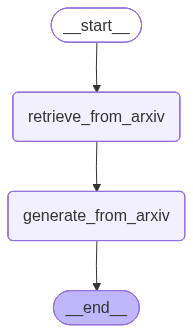

In [56]:
compiled_dynamic_arxiv_rag

## Step 7: Test the System

In [57]:
# Test with a question about multi-agent systems
result = compiled_dynamic_arxiv_rag.invoke({
    "question": "What are the main challenges in multi-agent systems?"
})

print("\n" + "="*70)
print("RESPONSE:")
print("="*70)
print(result["response"])


🤔 Processing user query: What are the main challenges in multi-agent systems?
🔍 Core terms: multi-agent systems OR distributed AI OR multi-agent coordination
🔍 Expanded terms: multi-agent systems OR MAS OR distributed AI OR multi-agent coordination OR autonomous agents OR agent-based systems
🔍 Domain: Artificial Intelligence / Multi-Agent Systems

📡 Strategy 1: Searching with field-specific query...
   ✅ Found 3 papers

📚 Total papers retrieved: 3

🔍 Filtering papers for relevance...
   ✅ [0.80] CH-MARL: Constrained Hierarchical Multiagent Reinforcement Learning for Sustainable Maritime Logistics
      Reason: The paper discusses multi-agent reinforcement learning in the context of autonomous agents addressing global challenges like emissions, which aligns with the challenges in multi-agent systems, especially in coordination and constraint enforcement.
   ✅ [0.90] Resource Abstraction for Reinforcement Learning in Multiagent Congestion Problems
      Reason: The paper directly addres

In [60]:
# Test with a question about quantum machine learning
result = compiled_dynamic_arxiv_rag.invoke({
    "question": "What is quantum transfer learning"
})

print("\n" + "="*70)
print("RESPONSE:")
print("="*70)
print(result["response"])


🤔 Processing user query: What is quantum transfer learning
🔍 Core terms: quantum transfer learning OR quantum machine learning
🔍 Expanded terms: quantum transfer learning OR QTL OR quantum machine learning OR QML OR quantum domain adaptation
🔍 Domain: Quantum Machine Learning

📡 Strategy 1: Searching with field-specific query...
   ✅ Found 3 papers

📚 Total papers retrieved: 3

🔍 Filtering papers for relevance...
   ❌ [0.20] Ab initio machine learning in chemical compound space - FILTERED OUT
      Reason: The paper focuses on machine learning for chemical compound space and ab initio methods, with no mention of quantum transfer learning or related concepts. It does not directly address quantum transfer learning.
   ❌ [0.20] Quantum Hardware-Enabled Molecular Dynamics via Transfer Learning - FILTERED OUT
      Reason: The paper focuses on quantum hardware and molecular dynamics simulations via transfer learning, but does not explicitly address the concept of quantum transfer learning 

---

## ✅ Activity #1 Complete!

### What We Built:
1. **Dynamic ArXiv Tool** (`retrieve_arxiv_information`) - Fetches papers on any topic
2. **Full PDF Processing** - Uses complete paper content
3. **RAG Pipeline** - Chunks, embeds, retrieves
4. **LangGraph Integration** - Same pattern as original

### Integration with Multi-Agent System:
if in future, we want to add this to our research team, we will simply do this:
```python
# Use in Research Team
arxiv_agent = create_agent(
    research_llm,
    [retrieve_arxiv_information],
    "You are a research assistant who retrieves ArXiv papers"
)
```

---

## Task 2: Helper Functions for Agent Graphs

We'll be using a number of agents, nodes, and supervisors in the rest of the notebook - and so it will help to have a collection of useful helper functions that we can leverage to make our lives easier going forward.

Let's start with the most simple one!

#### Import Wall

Here's a wall of imports we'll be needing going forward!

In [61]:
from typing import Any, Callable, List, Optional, TypedDict, Union

from langchain.agents import AgentExecutor, create_openai_functions_agent
from langchain.output_parsers.openai_functions import JsonOutputFunctionsParser
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage
from langchain_core.runnables import Runnable
from langchain_core.tools import BaseTool
from langchain_openai import ChatOpenAI

from langgraph.graph import END, StateGraph

### Agent Node Helper

Since we're going to be wrapping each of our agents into a node - it will help to have an easy way to create the node!

In [62]:
def agent_node(state, agent, name):
    result = agent.invoke(state)
    return {"messages": [HumanMessage(content=result["output"], name=name)]}

### Agent Creation Helper Function

Since we know we'll need to create agents to populate our agent nodes, let's use a helper function for that as well!

Notice a few things:

1. We have a standard suffix to append to our system messages for each agent to handle the tool calling and boilerplate prompting.
2. Each agent has its our scratchpad.
3. We're relying on OpenAI's function-calling API for tool selection
4. Each agent is its own executor.

In [63]:
def create_agent(
    llm: ChatOpenAI,
    tools: list,
    system_prompt: str,
) -> str:
    """Create a function-calling agent and add it to the graph."""
    system_prompt += ("\nWork autonomously according to your specialty, using the tools available to you."
    " Do not ask for clarification."
    " Your other team members (and other teams) will collaborate with you with their own specialties."
    " You are chosen for a reason!")
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                system_prompt,
            ),
            MessagesPlaceholder(variable_name="messages"),
            MessagesPlaceholder(variable_name="agent_scratchpad"),
        ]
    )
    agent = create_openai_functions_agent(llm, tools, prompt)
    executor = AgentExecutor(agent=agent, tools=tools)
    return executor

### Supervisor Helper Function

Finally, we need a "supervisor" that decides and routes tasks to specific agents.

Since each "team" will have a collection of potential agents - this "supervisor" will act as an "intelligent" router to make sure that the right agent is selected for the right task.

Notice that, at the end of the day, this "supervisor" is simply directing who acts next - or if the state is considered "done".

In [65]:
def create_team_supervisor(llm: ChatOpenAI, system_prompt, members) -> str:
    """An LLM-based router."""
    options = ["FINISH"] + members
    function_def = {
        "name": "route",
        "description": "Select the next role.",
        "parameters": {
            "title": "routeSchema",
            "type": "object",
            "properties": {
                "next": {
                    "title": "Next",
                    "anyOf": [
                        {"enum": options},
                    ],
                },
            },
            "required": ["next"],
        },
    }
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", system_prompt),
            MessagesPlaceholder(variable_name="messages"),
            (
                "system",
                "Given the conversation above, who should act next?"
                " Or should we FINISH? Select one of: {options}",
            ),
        ]
    ).partial(options=str(options), team_members=", ".join(members))
    return (
        prompt
        | llm.bind_functions(functions=[function_def], function_call="route")
        | JsonOutputFunctionsParser()
    )

## Task 3: Research Team - A LangGraph for Researching AI Usage Policy

Now that we have our RAG chain set-up and some awesome helper functions, we want to create a LangGraph related to researching a specific topic, in this case: How People Use AI!

We're going to start by equipping our Research Team with a few tools:

1. Tavily Search - aka "Google", for the most up to date information possible.
2. Our RAG chain - specific and high quality information about our topic.

Let's create those tools now!

### Tool Creation

As you can see below, some tools already come pre-packaged ready to use!

In [66]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily_tool = TavilySearchResults(max_results=5)

/var/folders/wz/l5kzl3495bj9gj9jt4p33xwh0000gn/T/ipykernel_97174/1911882425.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(max_results=5)


Creating a custom tool, however, is very straightforward.

> NOTE: You *must* include a docstring, as that is what the LLM will consider when deciding when to use this tool.

In [67]:
from typing import Annotated, List, Tuple, Union
from langchain_core.tools import tool

@tool
def retrieve_information(
    query: Annotated[str, "query to ask the retrieve information tool"]
    ):
  """Use Retrieval Augmented Generation to retrieve information about how people use AI"""
  return compiled_rag_graph.invoke({"question" : query})

> NOTE: We could just as easily use the LCEL chain directly, since nodes can be LCEL objects - but creating a tool helps explain the tool creation process at the same time.

### Research Team State

Since we're using LangGraph - we're going to need state!

Let's look at how we've created our state below.

In [68]:
import functools
import operator

from langchain_core.messages import AIMessage, BaseMessage, HumanMessage
from langchain_openai.chat_models import ChatOpenAI
import functools

class ResearchTeamState(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]
    team_members: List[str]
    next: str

Notice how we've used `messages`, `team_members`, and `next`.

These states will help us understand:

1. What we've done so far (`messages`)
2. Which team members we have access to (`team_members`)
3. Which team member is up next! (`next`)

### Research Team LLM

We'll be using `gpt-4o-mini` today. This LLM is going to be doing a lot of reasoning - but we also want to keep our costs down, so we'll use a lightweight; but powerful, model!

In [ ]:
research_llm = ChatOpenAI(model="gpt-4o-mini")

##### ❓ Question #1:

1. Why is a "powerful" LLM important for this use-case?

2. What tasks must our Agent perform that make it such that the LLM's reasoning capability is a potential limiter?

##### ✅ Answers:

__1.1__ Why a powerful LLM matters

A "powerful" LLM is important for this multi-agent use-case because:

- __Complex Decision Making__: The supervisor agents need to intelligently route tasks between different specialized agents based on understanding the context and requirements

- __Tool Selection__: Agents must reason about which tools to use from their available toolkit based on the specific task at hand

- __Natural Language Understanding__: The system needs to interpret user queries, extract meaningful concepts, and translate them into appropriate actions

- __Coordination__: The LLM must understand the capabilities and specialties of different team members to make optimal routing decisions

- __Context Maintenance__: In multi-turn conversations, the LLM needs to maintain context across interactions and understand the current state of the workflow

A weaker LLM might fail at:

- Understanding nuanced instructions in the system prompts.

- Keeping track of conversation flow across agents.

- Making correct decisions when multiple tools or agents could plausibly handle the task.

So the LLM’s reasoning, instruction-following, and long-context management are critical — a “small” or weaker model would likely hallucinate, misuse tools, or break the workflow.

__1.2__ Tasks where reasoning is a limiter

Tasks that make LLM reasoning capability a potential limiter include:

- __Supervisor Routing Logic__: The supervisor must analyze incoming requests and determine which agent is best suited to handle each task - poor reasoning leads to incorrect routing
- __Tool Selection and Sequencing__: Agents need to choose the right tools in the right order (e.g., search first, then analyze, then write) - weak reasoning leads to inefficient workflows
- __Quality Assessment__: Agents must evaluate the quality and relevance of retrieved information or generated content to decide if additional work is needed
- __Error Recovery__: When one strategy fails, the system needs to reason about alternative approaches and fallback strategies
- __Inter-Agent Communication__: Understanding when to pass control to another agent and what information to share requires sophisticated reasoning about task decomposition and collaboration

The reasoning capability directly impacts the system's ability to make intelligent decisions about workflow orchestration, tool usage, and quality control in the multi-agent environment.
These are cognitively heavy operations. Thus strong reasoning ability directly affects reliability. A weaker LLM may stop short, loop unnecessarily, or pick the wrong agent/tool, causing the entire workflow to stall or fail.


### Research Team Agents & Nodes

Now we can use our helper functions to create our agent nodes, with their related tools.

Let's start with our search agent node.

#### Research Team: Search Agent

We're going to give our agent access to the Tavily tool, power it with our GPT-4o Mini model, and then create its node - and name it `Search`.

In [70]:
search_agent = create_agent(
    research_llm,
    [tavily_tool],
    "You are a research assistant who can search for up-to-date info using the tavily search engine.",
)
search_node = functools.partial(agent_node, agent=search_agent, name="Search")

#### Research Team: RAG Agent Node

Now we can wrap our LCEL RAG pipeline in an agent node as well, using the LCEL RAG pipeline as the tool, as created above.

In [71]:
research_agent = create_agent(
    research_llm,
    [retrieve_information],
    "You are a research assistant who can provide specific information on how people use AI",
)
research_node = functools.partial(agent_node, agent=research_agent, name="HowPeopleUseAIRetriever")

### Research Team Supervisor Agent

Notice that we're not yet creating our supervisor *node*, simply the agent here.

Also notice how we need to provide a few extra pieces of information - including which tools we're using.

> NOTE: It's important to use the *exact* tool name, as that is how the LLM will reference the tool. Also, it's important that your tool name is all a single alphanumeric string!



In [72]:
research_supervisor_agent = create_team_supervisor(
    research_llm,
    ("You are a supervisor tasked with managing a conversation between the"
    " following workers:  Search, HowPeopleUseAIRetriever. Given the following user request,"
    " determine the subject to be researched and respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. "
    " You should never ask your team to do anything beyond research. They are not required to write content or posts."
    " You should only pass tasks to workers that are specifically research focused."
    " When finished, respond with FINISH."),
    ["Search", "HowPeopleUseAIRetriever"],
)

/var/folders/wz/l5kzl3495bj9gj9jt4p33xwh0000gn/T/ipykernel_97174/488856706.py:34: LangChainDeprecationWarning: The method `BaseChatOpenAI.bind_functions` was deprecated in langchain-openai 0.2.1 and will be removed in 1.0.0. Use :meth:`~langchain_openai.chat_models.base.ChatOpenAI.bind_tools` instead.
  | llm.bind_functions(functions=[function_def], function_call="route")


### Research Team Graph Creation

Now that we have our research team agent nodes created, and our supervisor agent - let's finally construct our graph!

We'll start by creating our base graph from our state, and then adding the nodes/agent we've created as nodes on our LangGraph.

In [73]:
research_graph = StateGraph(ResearchTeamState)

research_graph.add_node("Search", search_node)
research_graph.add_node("HowPeopleUseAIRetriever", research_node)
research_graph.add_node("ResearchSupervisor", research_supervisor_agent)

Now we can define our edges - include our conditional edge from our supervisor to our agent nodes.

Notice how we're always routing our agent nodes back to our supervisor!

In [74]:
research_graph.add_edge("Search", "ResearchSupervisor") 
research_graph.add_edge("HowPeopleUseAIRetriever", "ResearchSupervisor")
research_graph.add_conditional_edges(
    "ResearchSupervisor",
    lambda x: x["next"],
    {"Search": "Search", "HowPeopleUseAIRetriever": "HowPeopleUseAIRetriever", "FINISH": END},
)
research_graph.set_entry_point("ResearchSupervisor")

Now we can set our supervisor node as the entry point, and compile our graph!

In [75]:
compiled_research_graph = research_graph.compile()

#### Display Graph

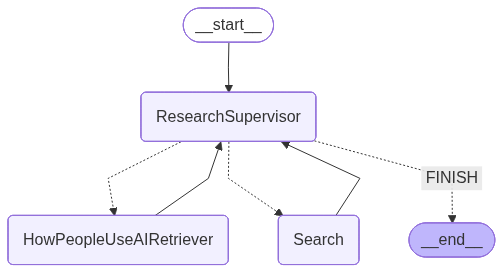

In [76]:
compiled_research_graph

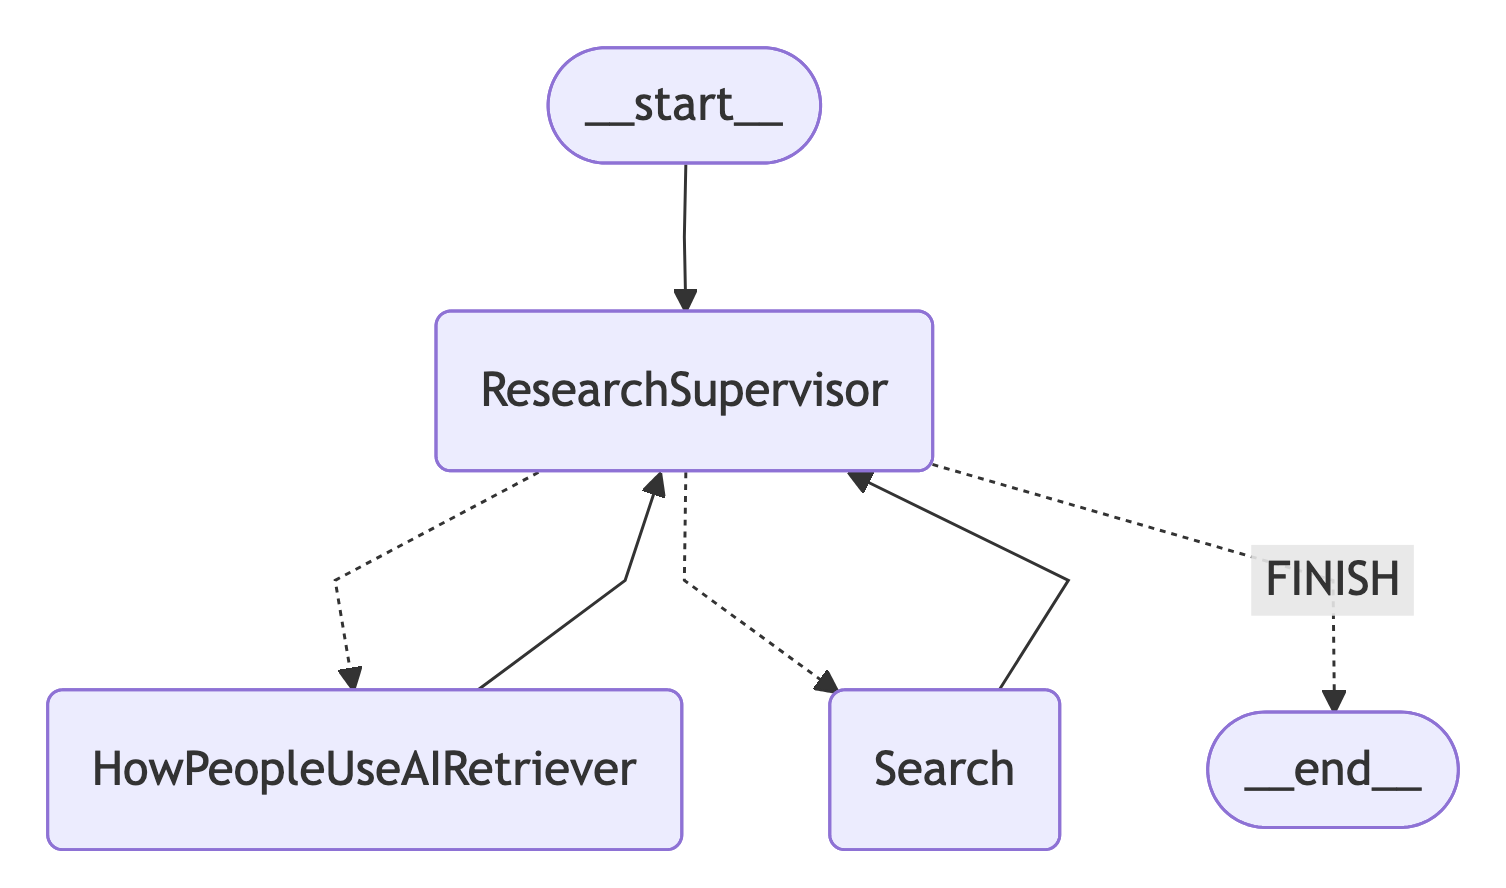

In [78]:
from IPython.display import Image, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles

display(
    Image(
        compiled_research_graph.get_graph().draw_mermaid_png(
            curve_style=CurveStyle.LINEAR,
            node_colors=NodeStyles(first="#ffdfba", last="#baffc9", default="#fad7de"),
            wrap_label_n_words=9,
            output_file_path=None,
            draw_method=MermaidDrawMethod.PYPPETEER,
            background_color="white",
            padding=10,
        )
    )
)

The next part is key - since we need to "wrap" our LangGraph in order for it to be compatible in the following steps - let's create an LCEL chain out of it!

This allows us to "broadcast" messages down to our Research Team LangGraph!

In [79]:
def enter_research_chain(message: str):
    results = {
        "messages": [HumanMessage(content=message)],
    }
    return results

research_chain = enter_research_chain | compiled_research_graph

Now, finally, we can take it for a spin!

In [80]:
for s in research_chain.stream(
    "How are people using AI to improve their lives?", {"recursion_limit": 100}
):
    if "__end__" not in s:
        print(s)
        print("---")

{'ResearchSupervisor': {'next': 'HowPeopleUseAIRetriever'}}
---
{'HowPeopleUseAIRetriever': {'messages': [HumanMessage(content="People are utilizing AI, particularly platforms like ChatGPT, to enhance their lives in various ways:\n\n1. **Education**: A considerable number of users leverage AI for tutoring and teaching assistance, making it a valuable tool for learning. Many also seek general how-to advice across a wide range of topics.\n\n2. **Technical Assistance**: Users frequently employ AI for technical help, which includes tasks related to computer programming, mathematical calculations, and data analysis.\n\n3. **Personal Expression**: Although less common, users do engage with AI for personal reflections and relationship discussions. This suggests a role for AI in social interactions and self-expression.\n\n4. **Efficiency in Tasks**: AI's ability to produce customized outputs, such as writing and software code, allows individuals to complete tasks more efficiently and creativel

##### 🏗️ Activity #2:

Using whatever drawing application you wish - please label the flow above on a diagram of your graph.

✅ Answer:
See below:

[GITHUB-COMPATIBLE] AI Research Flow - Based on Actual Execution
[OK] EXECUTED PATH: START → ResearchSupervisor → HowPeopleUseAIRetriever → ResearchSupervisor → END
[!] UNUSED: Search agent (query was answerable from PDF retriever)
[?] QUERY: 'How do people use AI?'
[✓] RESULT: Retrieved usage patterns (education, technical help, personal expression, decision-making, etc.) from PDF


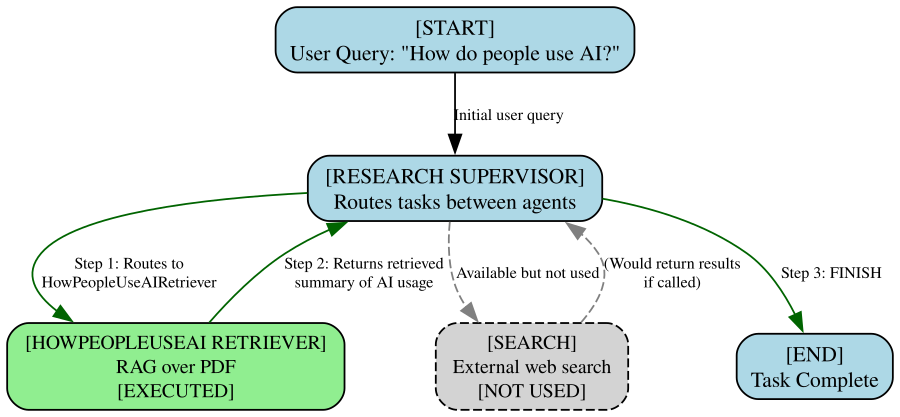

In [94]:
# GitHub-Compatible AI Research Flow Diagram

from graphviz import Digraph
from IPython.display import display

def create_github_compatible_ai_research_flow():
    dot = Digraph(comment='AI Research Flow - GitHub Compatible')
    dot.attr(rankdir='TD', size='3,4', dpi='300')

    # Node styles
    dot.attr('node', shape='box', style='filled,rounded', fontsize='10')

    # Add nodes with GitHub-compatible labels
    dot.node('START', '[START]\nUser Query: "How do people use AI?"',
             fillcolor='lightblue', fontsize='12')
    dot.node('supervisor', '[RESEARCH SUPERVISOR]\nRoutes tasks between agents',
             fillcolor='lightblue', fontsize='12')
    dot.node('Retriever', '[HOWPEOPLEUSEAI RETRIEVER]\nRAG over PDF\n[EXECUTED]',
             fillcolor='lightgreen', fontsize='11')
    dot.node('Search', '[SEARCH]\nExternal web search\n[NOT USED]',
             fillcolor='lightgrey', style='filled,dashed,rounded', fontsize='11')
    dot.node('END', '[END]\nTask Complete',
             fillcolor='lightblue', fontsize='12')

    # Add edges with labels showing the actual execution flow
    dot.edge('START', 'supervisor', label='Initial user query', fontsize='9')
    dot.edge('supervisor', 'Retriever',
             label='Step 1: Routes to\nHowPeopleUseAIRetriever', color='darkgreen', fontsize='9')
    dot.edge('Retriever', 'supervisor',
             label='Step 2: Returns retrieved\nsummary of AI usage', color='darkgreen', fontsize='9')
    dot.edge('supervisor', 'Search',
             label='Available but not used', style='dashed', color='gray', fontsize='9')
    dot.edge('Search', 'supervisor',
             label='(Would return results\nif called)', style='dashed', color='gray', fontsize='9')
    dot.edge('supervisor', 'END',
             label='Step 3: FINISH', color='darkgreen', fontsize='9')

    return dot

# Print execution summary with GitHub-compatible symbols
print("[GITHUB-COMPATIBLE] AI Research Flow - Based on Actual Execution")
print("=" * 70)
print("[OK] EXECUTED PATH: START → ResearchSupervisor → HowPeopleUseAIRetriever → ResearchSupervisor → END")
print("[!] UNUSED: Search agent (query was answerable from PDF retriever)")
print("[?] QUERY: 'How do people use AI?'")
print("[✓] RESULT: Retrieved usage patterns (education, technical help, personal expression, decision-making, etc.) from PDF")
print("=" * 70)

# Display the GitHub-compatible graph
github_ai_research_flow = create_github_compatible_ai_research_flow()
display(github_ai_research_flow)


##### ❓ Question #2:

How could you make sure your Agent uses specific tools that you wish it to use? Are there any ways to concretely set a flow through tools?

##### ✅ Answer:

There are several ways to control agent tool usage and enforce specific flows in LangGraph:

##### __2.1 Restrict the Toolset__  
When creating the agent, only provide the tools you want it to use. If other tools are omitted, the agent cannot access them.  

```python
# Example: force agent to only use the retriever tool
retriever_tools = [how_people_use_ai_retriever_tool]

retriever_agent = create_agent(
    llm=ChatOpenAI(model="gpt-4o-mini"),
    tools=retriever_tools,
    system_prompt="You are a retriever agent. Always use the retriever tool when asked about AI usage."
)
```


##### __2.2 Enforce Flow in the Graph__  
With LangGraph, you can hard-wire execution order using edges. This guarantees that certain tools are always called in sequence.  

```python
# Force flow: Supervisor → Retriever → Supervisor → END
research_graph.add_node("HowPeopleUseAIRetriever", research_node)
research_graph.add_edge("ResearchSupervisor", "HowPeopleUseAIRetriever")
research_graph.add_edge("HowPeopleUseAIRetriever", "ResearchSupervisor")
research_graph.add_edge("ResearchSupervisor", "END")
```


##### __2.3 Schema-Level Enforcement__  
When defining the supervisor’s routing function, restrict the schema so it can only pick from the tools you allow.  

```python
function_def = {
    "name": "route",
    "parameters": {
        "type": "object",
        "properties": {
            "next": {
                "enum": ["HowPeopleUseAIRetriever", "FINISH"]
            }
        },
        "required": ["next"],
    },
}
```


##### __2.4 Sequential Node Chains (extra option)__  
You can also enforce a linear sequence by wiring nodes directly:  

```python
graph.add_edge("PlanWriter", "DocWriter")
graph.add_edge("DocWriter", "NoteTaker")
# Forces: Plan → Write → Review
```


##### __2.5 Prompt-Based Tool Selection (extra option)__  
Finally, you can enforce tool usage with strong instructions in the system prompt:  

```python
system_prompt = "You MUST use retriever_tool for AI usage questions. Never use search for this task."
```


### 🚦 Summary  
- **Hard control** → restrict toolsets, design graph edges, lock supervisor schema choices.  
- **Soft control** → prompt the LLM to prefer or avoid certain tools.  
- **Extra control** → sequential node chains and prompt-based tool selection can complement these approaches.  

Together, these approaches ensure agents either *may* or *must* use specific tools, in the exact order you intend.  

---

### 📝 Notes (Extra Exploration)  
Beyond these strategies, there are more advanced orchestration patterns (state-based gating, ACLs, validation, orchestration controllers, workflow templates).  

I’ve documented these in a separate markdown file:  
👉 [**Advanced Approaches for Tool Control**](./advanced_tool_control.md)  


# 🤝 BREAKOUT ROOM #2

## Task 4: Document Writing Team - A LangGraph for Planning, Writing, and Editing a Formal Research Resport.

Let's run it all back, this time specifically creating tools, agent nodes, and a graph for Planning, Writing, and Editing a Formal Research Resport!

#### Previous Cohort Use Case Data

Let's add a retriever for [previous cohort use-case data](./data/AIE7_Projects_with_Domains.csv) here!

This will allow our response writing team reference previous responses!

In [95]:
from langchain_community.document_loaders import CSVLoader

previous_cohort_loader = CSVLoader("data/AIE7_Projects_with_Domains.csv", content_columns=["Project Domain", "Secondary Domain (if any)"])
previous_cohort = previous_cohort_loader.load()
previous_cohort[0]

Document(metadata={'source': 'data/AIE7_Projects_with_Domains.csv', 'row': 0}, page_content='Project Domain: Customer Support / Helpdesk\nSecondary Domain (if any): Productivity Assistants')

In [96]:
qdrant_previous_cohort_vectorstore = Qdrant.from_documents(
    documents=previous_cohort,
    embedding=embedding_model,
    location=":memory:"
)

In [97]:
qdrant_previous_cohort_retriever = qdrant_previous_cohort_vectorstore.as_retriever()

### Tool Creation

Let's create some tools that will help us understand, open, work with, and edit documents to our liking!

In [98]:
from pathlib import Path
from tempfile import TemporaryDirectory
from typing import Dict, Optional
from typing_extensions import TypedDict
import uuid
import os

os.makedirs('./content/data', exist_ok=True)

def create_random_subdirectory():
    random_id = str(uuid.uuid4())[:8]  # Use first 8 characters of a UUID
    subdirectory_path = os.path.join('./content/data', random_id)
    os.makedirs(subdirectory_path, exist_ok=True)
    return subdirectory_path

WORKING_DIRECTORY = Path(create_random_subdirectory())

@tool
def create_outline(
    points: Annotated[List[str], "List of main points or sections."],
    file_name: Annotated[str, "File path to save the outline."],
) -> Annotated[str, "Path of the saved outline file."]:
    """Create and save an outline."""
    with (WORKING_DIRECTORY / file_name).open("w") as file:
        for i, point in enumerate(points):
            file.write(f"{i + 1}. {point}\n")
    return f"Outline saved to {file_name}"


@tool
def read_document(
    file_name: Annotated[str, "File path to save the document."],
    start: Annotated[Optional[int], "The start line. Default is 0"] = None,
    end: Annotated[Optional[int], "The end line. Default is None"] = None,
) -> str:
    """Read the specified document."""
    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()
    if start is not None:
        start = 0
    return "\n".join(lines[start:end])

@tool
def write_document(
    content: Annotated[str, "Text content to be written into the document."],
    file_name: Annotated[str, "File path to save the document."],
) -> Annotated[str, "Path of the saved document file."]:
    """Create and save a text document."""
    with (WORKING_DIRECTORY / file_name).open("w") as file:
        file.write(content)
    return f"Document saved to {file_name}"

### Previous Cohort Use Case Data
@tool 
def reference_previous_responses(
    query: Annotated[str, "The query to search for in the previous responses."],
) -> Annotated[str, "The previous responses that match the query."]:
    """Search for previous responses that match the query."""
    return qdrant_previous_cohort_retriever.invoke(query)


@tool
def edit_document(
    file_name: Annotated[str, "Path of the document to be edited."],
    inserts: Annotated[
        Dict[int, str],
        "Dictionary where key is the line number (1-indexed) and value is the text to be inserted at that line.",
    ] = {},
) -> Annotated[str, "Path of the edited document file."]:
    """Edit a document by inserting text at specific line numbers."""

    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()

    sorted_inserts = sorted(inserts.items())

    for line_number, text in sorted_inserts:
        if 1 <= line_number <= len(lines) + 1:
            lines.insert(line_number - 1, text + "\n")
        else:
            return f"Error: Line number {line_number} is out of range."

    with (WORKING_DIRECTORY / file_name).open("w") as file:
        file.writelines(lines)

    return f"Document edited and saved to {file_name}"

##### 🏗️ Activity #3:

Describe, briefly, what each of these tools is doing in your own words.

## ✅ Answer:

Based on the Document Writing Team tools, here's what each tool does:

##### __1. `create_outline`__

__What it does__: Creates a structured outline file from a list of main points or sections.

- __Input__: Takes a list of topics/points and a filename
- __Action__: Writes a numbered list (1. Point 1, 2. Point 2, etc.) to a file
- __Purpose__: Helps organize ideas before writing, like creating a table of contents or bullet points for a document

##### __2. `read_document`__

__What it does__: Reads and returns the contents of an existing document file.

- __Input__: Takes a filename and optional start/end line numbers
- __Action__: Opens the file and reads the text content (or specific lines)
- __Purpose__: Allows agents to review what's already been written, check existing content, or read reference materials

##### __3. `write_document`__

__What it does__: Creates a new document file with the provided content.

- __Input__: Takes text content and a filename
- __Action__: Creates a new file and writes the content to it
- __Purpose__: Generates the actual written output - reports, articles, responses, etc.

##### __4. `reference_previous_responses`__

__What it does__: Searches through previous cohort project data to find relevant examples.

- __Input__: Takes a search query
- __Action__: Uses vector similarity search on the CSV data of past projects
- __Purpose__: Helps agents learn from previous work and maintain consistency with past responses

##### __5. `edit_document`__

__What it does__: Modifies an existing document by inserting text at specific line numbers.

- __Input__: Takes a filename and a dictionary of line numbers → text to insert
- __Action__: Opens the file, inserts new text at specified positions, saves the updated file
- __Purpose__: Allows for precise editing and revision - adding sections, fixing content, or inserting improvements

##### __How They Work Together:__

These tools create a complete __document workflow__:

1. __Plan__ (`create_outline`) → __Research__ (`reference_previous_responses`) → __Write__ (`write_document`) → __Review__ (`read_document`) → __Edit__ (`edit_document`)

This gives the Document Writing Team agents everything they need to collaboratively create, review, and refine written content - just like a real writing team would work!


### Document Writing State

Just like with our Research Team state - we want to keep track of a few things, however this time - we also want to keep track of which files we've created - so let's add that here!

In [99]:
import operator
from pathlib import Path

class DocWritingState(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]
    team_members: str
    next: str
    current_files: str

### Document Writing Prelude Function

Since we have a working directory - we want to be clear about what our current working directory looks like - this helper function will allow us to do that cleanly!

In [100]:
def prelude(state):
    written_files = []
    if not WORKING_DIRECTORY.exists():
        WORKING_DIRECTORY.mkdir()
    try:
        written_files = [
            f.relative_to(WORKING_DIRECTORY) for f in WORKING_DIRECTORY.rglob("*")
        ]
    except:
        pass
    if not written_files:
        return {**state, "current_files": "No files written."}
    return {
        **state,
        "current_files": "\nBelow are files your team has written to the directory:\n"
        + "\n".join([f" - {f}" for f in written_files]),
    }

### Document Writing Node Creation



In [101]:
authoring_llm = ChatOpenAI(model="gpt-4o-mini")

In [103]:
doc_writer_agent = create_agent(
    authoring_llm,
    [write_document, edit_document, read_document],
    ("You are an expert writing customer assistance responses.\n"
    "Below are files currently in your directory:\n{current_files}"),
)
context_aware_doc_writer_agent = prelude | doc_writer_agent
doc_writing_node = functools.partial(
    agent_node, agent=context_aware_doc_writer_agent, name="DocWriter"
)

note_taking_agent = create_agent(
    authoring_llm,
    [create_outline, read_document, reference_previous_responses],
    ("You are an expert senior researcher tasked with writing a customer assistance outline and"
    " taking notes to craft a customer assistance response.\n{current_files}"),
)
context_aware_note_taking_agent = prelude | note_taking_agent
note_taking_node = functools.partial(
    agent_node, agent=context_aware_note_taking_agent, name="NoteTaker"
)

copy_editor_agent = create_agent(
    authoring_llm,
    [write_document, edit_document, read_document],
    ("You are an expert copy editor who focuses on fixing grammar, spelling, and tone issues\n"
    "Below are files currently in your directory:\n{current_files}"),
)
context_aware_copy_editor_agent = prelude | copy_editor_agent
copy_editing_node = functools.partial(
    agent_node, agent=context_aware_copy_editor_agent, name="CopyEditor"
)

authoring_supervisor_agent = create_team_supervisor(
    authoring_llm,
    ("You are a supervisor tasked with managing a conversation between the"
    " following workers: {team_members}. You should always verify the technical"
    " contents after any edits are made. "
    "Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When each team is finished,"
    " you must respond with FINISH."),
    ["DocWriter", "NoteTaker", "CopyEditor"],
)

### Document Writing Team LangGraph Construction

This part is almost exactly the same (with a few extra nodes) as our Research Team LangGraph construction - so we'll leave it as one block!

In [104]:
authoring_graph = StateGraph(DocWritingState)
authoring_graph.add_node("DocWriter", doc_writing_node)
authoring_graph.add_node("NoteTaker", note_taking_node)
authoring_graph.add_node("CopyEditor", copy_editing_node)
authoring_graph.add_node("AuthoringSupervisor", authoring_supervisor_agent)

authoring_graph.add_edge("DocWriter", "AuthoringSupervisor")
authoring_graph.add_edge("NoteTaker", "AuthoringSupervisor")
authoring_graph.add_edge("CopyEditor", "AuthoringSupervisor")

authoring_graph.add_conditional_edges(
    "AuthoringSupervisor",
    lambda x: x["next"],
    {
        "DocWriter": "DocWriter",
        "NoteTaker": "NoteTaker",
        "CopyEditor" : "CopyEditor",
        "FINISH": END,
    },
)

authoring_graph.set_entry_point("AuthoringSupervisor")

In [105]:
compiled_authoring_graph = authoring_graph.compile()

#### Display Graph

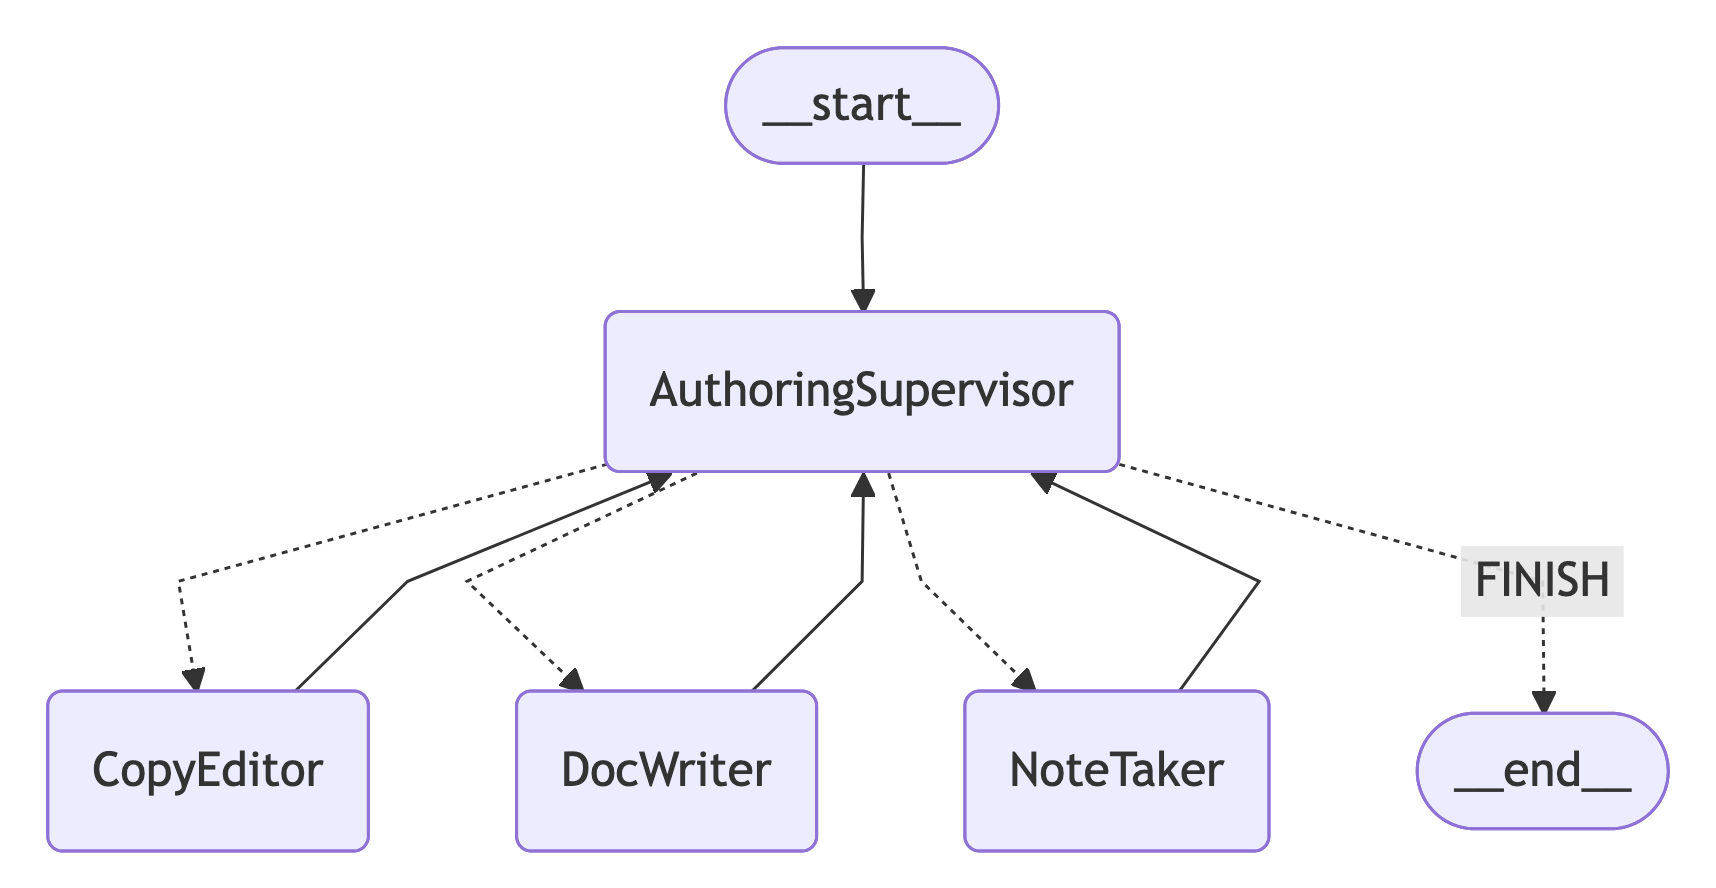

In [107]:
# compiled_authoring_graph

from IPython.display import Image, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles

display(
    Image(
        compiled_authoring_graph.get_graph().draw_mermaid_png(
            curve_style=CurveStyle.LINEAR,
            node_colors=NodeStyles(first="#ffdfba", last="#baffc9", default="#fad7de"),
            wrap_label_n_words=9,
            output_file_path=None,
            draw_method=MermaidDrawMethod.PYPPETEER,
            background_color="white",
            padding=10,
        )
    )
)

Just as before - we'll need to create an "interface" between the level above, and our graph.

In [108]:
def enter_authoring_chain(message: str, members: List[str]):
    results = {
        "messages": [HumanMessage(content=message)],
        "team_members": ", ".join(members),
    }
    return results

authoring_chain = (
    functools.partial(enter_authoring_chain, members=authoring_graph.nodes)
    | compiled_authoring_graph
)

Now we can test this out!

> NOTE: It is possible you may see an error here - rerun the cell to clear.

In [109]:
for s in authoring_chain.stream(
    "What are the most common use-cases in this data. What are the most common domains?",
    {"recursion_limit": 100},
):
    if "__end__" not in s:
        print(s)
        print("---")

{'AuthoringSupervisor': {'next': 'DocWriter'}}
---
{'DocWriter': {'messages': [HumanMessage(content='The most common use cases and domains for customer assistance can vary based on the industry and customer needs. However, some general common use cases include:\n\n1. **Product Inquiries:** Customers often seek information about products, including specifications, availability, features, and benefits.\n\n2. **Order Support:** Many customers require assistance with placing, tracking, changing, or canceling orders.\n\n3. **Technical Support:** Customers might need help with troubleshooting, installation, or usage of a product or service.\n\n4. **Billing Questions:** Queries regarding invoices, payment methods, refunds, or account balances are prevalent.\n\n5. **Returns and Exchanges:** Customers frequently ask about the process to return or exchange products.\n\n6. **Account Management:** Users often require help with creating, accessing, or modifying their accounts and settings.\n\n7. **

## Task 5: Meta-Supervisor and Full Graph

Finally, now that we have our two LangGraph agents (some of which are already multi-agent), we can build a supervisor that sits above all of them!

The final process, surprisingly, is quite straight forward!

Let's jump in!

First off - we'll need to create our supervisor agent node.

In [110]:
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage
from langchain_openai.chat_models import ChatOpenAI

super_llm = ChatOpenAI(model="gpt-4o-mini")

super_supervisor_agent = create_team_supervisor(
    super_llm,
    "You are a supervisor tasked with managing a conversation between the"
    " following teams: {team_members}. Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When all workers are finished,"
    " you must respond with FINISH.",
    ["Research team", "Response team"],
)

We'll also create our new state - as well as some methods to help us navigate the new state and the subgraphs.

> NOTE: We only pass the most recent message from the parent graph to the subgraph, and we only extract the most recent message from the subgraph to include in the state of the parent graph.

In [111]:
class State(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]
    next: str

def get_last_message(state: State) -> str:
    return state["messages"][-1].content

def join_graph(response: dict):
    return {"messages": [response["messages"][-1]]}

Next, we'll create our base graph.

Notice how each node we're adding is *AN ENTIRE LANGGRAPH AGENT* (wrapped into an LCEL chain with our helper functions above).

In [112]:
super_graph = StateGraph(State)

super_graph.add_node("Research team", get_last_message | research_chain | join_graph)
super_graph.add_node("Response team", get_last_message | authoring_chain | join_graph)
super_graph.add_node("SuperSupervisor", super_supervisor_agent)

Next, we'll create our edges!

This process is completely idenctical to what we've seen before - just addressing the LangGraph subgraph nodes instead of individual nodes.

In [113]:
super_graph.add_edge("Research team", "SuperSupervisor")
super_graph.add_edge("Response team", "SuperSupervisor")
super_graph.add_conditional_edges(
    "SuperSupervisor",
    lambda x: x["next"],
    {
        "Response team": "Response team",
        "Research team": "Research team",
        "FINISH": END,
    },
)
super_graph.set_entry_point("SuperSupervisor")

In [116]:
compiled_super_graph = super_graph.compile()
# compiled_super_graph

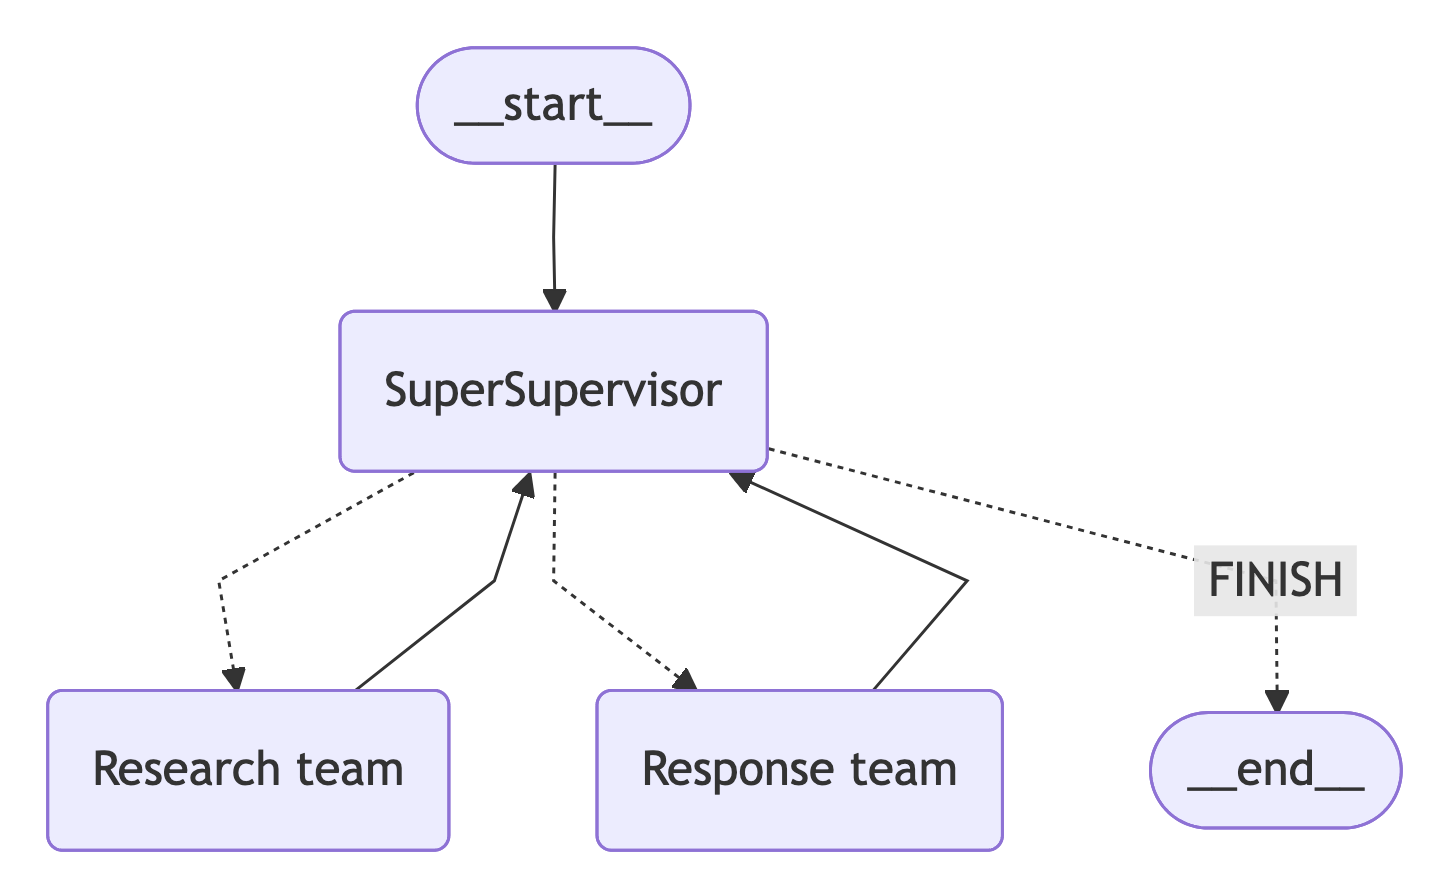

In [117]:
from IPython.display import Image, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles

display(
    Image(
        compiled_super_graph.get_graph().draw_mermaid_png(
            curve_style=CurveStyle.LINEAR,
            node_colors=NodeStyles(first="#ffdfba", last="#baffc9", default="#fad7de"),
            wrap_label_n_words=9,
            output_file_path=None,
            draw_method=MermaidDrawMethod.PYPPETEER,
            background_color="white",
            padding=10,
        )
    )
)

That's it!

Now we can finally use our full agent!

In [118]:
WORKING_DIRECTORY = Path(create_random_subdirectory())

for s in compiled_super_graph.stream(
    {
        "messages": [
            HumanMessage(
                content="Write a report on the rise of context engineering in the LLM Space in 2025, and how it's impacting how people are using AI."
            )
        ],
    },
    {"recursion_limit": 30},
):
    if "__end__" not in s:
        print(s)
        print("---")

{'SuperSupervisor': {'next': 'Research team'}}
---
{'Research team': {'messages': [HumanMessage(content='# Report on the Rise of Context Engineering in the LLM Space in 2025\n\n## Introduction\n\nBy 2025, the field of artificial intelligence, particularly in the realm of large language models (LLMs), has witnessed a significant evolution marked by the rise of context engineering. This burgeoning discipline has transformed how developers interact with AI systems, shifting the focus from simple prompt engineering to a comprehensive architecture of context management. This report explores the concept of context engineering, its rise in prominence, the techniques associated with it, and its profound implications for the utilization of AI.\n\n## Understanding Context Engineering\n\nContext engineering refers to the strategic design and management of the environment, input data, and interaction flows that inform how AI systems, especially LLMs, interpret and respond to user inputs. Unlike tr

## SAMPLE POST!

### Report on the Rise of Context Engineering in the LLM Space in 2025

#### Introduction
As we move further into 2025, the landscape of artificial intelligence continues to evolve, particularly in the domain of large language models (LLMs). One significant trend emerging is "context engineering," which has begun to outpace the earlier focus on prompt engineering. This report explores how context engineering is reshaping the dynamics of AI usage, enhancing the capabilities of LLMs to perform complex tasks, and ultimately influencing the way users interact with AI technologies.

#### The Emergence of Context Engineering
In previous years, prompt engineering involved crafting inputs to guide LLMs to generate desired outputs. However, by 2025, the limitations of traditional prompt engineering have become evident, especially as applications require more dynamic interactions and multi-turn dialogues. Context engineering has emerged as a new paradigm, prioritizing the construction of strategies and systems that enable LLMs to access and utilize extensive contextual information effectively.

Modern LLMs, such as GPT-4 Turbo and Claude 3, now boast context windows that can handle up to 1 million tokens. This substantial increase allows these models to grasp more extensive content, such as books or lengthy documents, fundamentally changing what they can achieve in real-world applications.

#### Key Developments in Context Engineering
1. **Dynamic Knowledge Management**: The shift towards context engineering facilitates more sophisticated knowledge management within AI systems. These systems now use persistent memory and adaptive reasoning, enabling them to maintain context across interactions. For example, agent-based LLMs can now engage in workflows requiring multiple exchanges, which is vital for complex applications requiring follow-ups and extended dialogues.

2. **Improved Context Lengths**: Advances in transformer architectures have led to the possibility of extending native context lengths dramatically. As a result, LLMs can process larger datasets directly, enhancing their capacity to deliver accurate and relevant outputs without extensive re-prompting.

3. **Context Compression and Retrieval**: Techniques such as context compression, where information is stored externally or synthesized to maximize relevance, are gaining traction. Methods identified in recent studies highlight the importance of integrating efficient retrieval systems and summarization techniques to make the most of the available context.

4. **The Rise of Multi-Agent Systems**: In 2025, LLM applications are increasingly shifting towards multi-agent architectures, where different AI agents work collaboratively, leveraging various tools and pieces of information to improve output accuracy and reduce operational inefficiencies.

#### Impact on AI Usage
The implications of context engineering are far-reaching and transformative for users and organizations:

- **Enhanced Accuracy**: Enterprises adopting context engineering report accuracy rates of 90-95%, a significant improvement over the 65-75% typically associated with earlier methods. This rise in performance is generating more trust in AI systems across various sectors.

- **Faster Deployment and Cost Efficiency**: Organizations employing structured context engineering have demonstrated a 3x increase in the speed of bringing AI solutions to production and a 40% reduction in operational costs compared to traditional prompt-based methodologies.

- **Adaptability and Scalability**: Context-engineered systems are inherently more adaptable, allowing businesses to scale AI applications rapidly in response to evolving needs without overhauling the underlying architecture.

- **Augmentation of Human Intelligence**: As context engineering allows AI systems to interact in more meaningful ways, they are increasingly positioned as partners in decision-making processes, rather than mere tools. This evolution enhances the collaborative potential between humans and AI.

#### Conclusion
The rise of context engineering marks a critical turning point in the development and application of LLMs. As AI systems become increasingly capable of managing and utilizing complex contextual information, they are set to enhance user experiences, improve efficiency, and drive new innovations across industries. Organizations that embrace this trend will likely lead the charge into a future where AI is not just a tool for automation but a collaborative partner in problem-solving and creativity.

## 🏗️ Task 6: Advanced Build — LinkedIn ML Paper Post Generation System

The goal of this system is to generate professional LinkedIn posts about Machine Learning papers.\
It uses multiple specialized teams, each with its own supervisor, coordinated by a meta-supervisor.\
The system ensures posts are __accurate__, __professionally styled__, and __engaging__.

---

### 📋 System Architecture

__🏗️ Overview__\
This multi-agent architecture automates the workflow of:

1. Researching and summarizing an ML paper using ArXiv integration.
2. Drafting a LinkedIn-style post with professional formatting.
3. Verifying accuracy and adherence to LinkedIn's tone and length.
4. Optimizing for engagement before final approval.

---

### 🔄 Workflow

📝 __User Input__: ML Paper URL/Title/ArXiv ID\
↓\
🎯 __Meta-Supervisor__ — decides which team should act next\
↓\
👥 __Content Research Team__ (with ResearchSupervisor)

- 🔬 __ArXiv Paper Researcher__ (`retrieve_arxiv_information`, `tavily_tool`) → fetches paper from ArXiv and extracts key findings, methodology, results
- ✍️ __LinkedIn Content Writer__ (`create_linkedin_post`, `reference_previous_responses`) → drafts LinkedIn post using professional tone, hashtags, and formatting based on successful past posts

↓\
🎯 __Meta-Supervisor__\
↓\
✅ __Verification & Quality Team__ (with AuthoringSupervisor)

- 🔍 __Technical Fact Checker__ (`verify_technical_accuracy`, `read_document`) → cross-checks claims against the original ML paper for accuracy
- 📱 __LinkedIn Style Reviewer__ (`check_linkedin_style`, `edit_document`) → ensures LinkedIn formatting, professional tone, hashtags, emojis, and enforces __3000-character limit__
- 💡 __Engagement Optimizer__ (`optimize_engagement`, `write_document`) → evaluates and enhances content for professional discussion, shares, and comments

↓\
🎯 __Meta-Supervisor__\
↓\
🏁 __Final LinkedIn Post__ (saved to file)

---

### 🛠️ Implementation Using Notebook Patterns

__Content Research Team State__:

```python
class ContentTeamState(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]
    paper_input: str
    paper_analysis: dict
    draft_post: str
    team_members: List[str]
    next: str
```

__Verification Team State__:

```python
class VerificationTeamState(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]
    draft_post: str
    verification_results: dict
    current_files: str
    team_members: str
    next: str
```

__Key Tools__ (extending notebook's document tools):

```python
@tool
def create_linkedin_post(paper_analysis: dict, platform_style: str) -> str:
    """Create LinkedIn post from ML paper analysis"""
    # Uses paper_analysis + LinkedIn best practices

@tool  
def verify_technical_accuracy(post: str, paper_analysis: dict) -> dict:
    """Verify post claims against original paper"""
    # Cross-reference with source material

@tool
def check_linkedin_style(post: str) -> dict:
    """Check LinkedIn formatting and 3000-char limit"""
    # Validate professional tone, hashtags, length

@tool
def optimize_engagement(post: str) -> str:
    """Enhance post for LinkedIn engagement"""
    # Add CTAs, questions, professional hooks
```

---

### 🔧 Key Features

__Content Research Team__

- Leverages existing `retrieve_arxiv_information` for paper fetching
- Uses `reference_previous_responses` to learn from successful LinkedIn posts
- Employs `tavily_tool` for additional context if needed
- Creates initial draft using LinkedIn best practices

__Verification & Quality Team__

- Extends existing document tools (`read_document`, `write_document`, `edit_document`)
- Validates __technical accuracy__ against source paper
- Enforces __LinkedIn style compliance__ (tone, hashtags, emojis, formatting)
- Applies __hard 3000-character limit__ with automatic truncation
- Optimizes for __professional engagement__ and discussion

__Multi-Level Supervision__ (following notebook pattern)

- __Content Team Supervisor__: Manages Research → Writing sequence
- __Verification Team Supervisor__: Coordinates Fact Check → Style Check → Engagement Optimization
- __Meta-Supervisor__: Orchestrates Content Team → Verification Team → Final Approval

---

### 🎯 Quality Controls

- ✅ __ArXiv Integration__: Fetches accurate, up-to-date ML papers
- ✅ __Technical Verification__: No hallucinations or misrepresentations
- ✅ __LinkedIn Style Compliance__: Professional tone, proper formatting
- ✅ __Character Limit Enforcement__: Strict 3000-character limit
- ✅ __Engagement Optimization__: CTAs, questions, professional hooks
- ✅ __Iterative Refinement__: Verification team can request revisions
- ✅ __File Management__: Uses notebook's document tools for version control

---

### 🚀 Implementation Advantages

__Leverages Existing Infrastructure__:

- Reuses `retrieve_arxiv_information` for paper fetching
- Extends document writing tools for LinkedIn content
- Follows established supervisor patterns from notebook
- Uses proven state management approaches

__Enhanced Capabilities__:

- __ArXiv Integration__: Direct paper fetching vs manual input
- __Multi-Stage Verification__: Technical + Style + Engagement review
- __Platform Specialization__: LinkedIn-specific optimization
- __Quality Assurance__: Multiple checkpoints prevent poor content

This creates a production-ready system that can reliably generate high-quality, accurate, and engaging LinkedIn posts about ML papers while maintaining the robust multi-agent coordination patterns established in the notebook!


##### LinkedIn Post Generation Tools

Custom tools for creating, analyzing, and optimizing LinkedIn posts about ML papers.
These tools will be used by our LinkedIn agent team.


In [185]:
import os
import re
import requests
from typing import Annotated, Dict, List
from langchain_core.tools import tool
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

# Initialize LLM for tool operations
llm = ChatOpenAI(model="gpt-4o-mini")

In [186]:
@tool
def fetch_arxiv_paper(
    paper_identifier: Annotated[str, "ArXiv ID, URL, or paper title to fetch"]
) -> Dict[str, str]:
    """
    Fetch and extract key information from an ML paper on ArXiv.
    Returns structured data about the paper.
    """
    try:
        from langchain_community.document_loaders import ArxivLoader
        
        print(f"📄 Fetching paper: {paper_identifier}")
        
        # Handle different input types (ArXiv ID, URL, or title)
        if paper_identifier.startswith("http"):
            # Extract ArXiv ID from URL
            arxiv_id = paper_identifier.split("/")[-1].replace(".pdf", "")
            query = arxiv_id
        elif "." in paper_identifier and len(paper_identifier) < 20:
            # Looks like ArXiv ID (e.g., "2301.12345")
            query = paper_identifier
        else:
            # Treat as paper title
            query = paper_identifier
        
        # Fetch paper using ArxivLoader
        loader = ArxivLoader(
            query=query,
            load_max_docs=1,
            load_all_available_meta=True
        )
        
        documents = loader.load()
        
        if not documents:
            return {
                "error": f"Could not find paper: {paper_identifier}",
                "title": "",
                "authors": "",
                "abstract": "",
                "content": ""
            }
        
        doc = documents[0]
        
        return {
            "title": doc.metadata.get("Title", "Unknown Title"),
            "authors": doc.metadata.get("Authors", "Unknown Authors"),
            "abstract": doc.metadata.get("Summary", "No abstract available"),
            "content": doc.page_content[:2000],  # First 2000 chars of content
            "arxiv_url": doc.metadata.get("entry_id", ""),
            "published": doc.metadata.get("Published", "")
        }
        
    except Exception as e:
        return {
            "error": f"Error fetching paper: {str(e)}",
            "title": "",
            "authors": "",
            "abstract": "",
            "content": ""
        }


In [187]:
@tool
def analyze_ml_paper(paper_identifier: str) -> Dict[str, str]:
    # First fetch the paper internally
    paper_data = fetch_arxiv_paper.invoke(paper_identifier)
    # Then analyze it
    # Include paper_data in the returned analysis
    """
    Analyze ML paper and extract key insights for LinkedIn post creation.
    Returns structured analysis with key findings, significance, and applications.
    """
    try:
        analysis_prompt = ChatPromptTemplate.from_messages([
            ("system", """You are an expert ML researcher analyzing papers for LinkedIn posts.

Extract and analyze the following from the paper:
1. Core contribution/innovation
2. Key technical approach or methodology
3. Main results/findings
4. Real-world applications or impact
5. Significance to the ML community
6. Target audience (researchers, practitioners, general tech audience)

Return a JSON object with:
- "core_contribution": Main innovation in 1-2 sentences
- "methodology": Technical approach in simple terms
- "key_results": Most important findings
- "applications": Real-world use cases
- "significance": Why this matters to ML community
- "target_audience": Who should care about this
- "complexity_level": "beginner", "intermediate", or "advanced"

Be concise but informative. Focus on what makes this paper interesting and valuable."""),
            ("human", """Paper Title: {title}

Authors: {authors}

Abstract: {abstract}

Content Sample: {content}

Please analyze this ML paper for LinkedIn post creation.""")
        ])
        
        chain = analysis_prompt | llm | StrOutputParser()
        result = chain.invoke({
            "title": paper_data.get("title", ""),
            "authors": paper_data.get("authors", ""),
            "abstract": paper_data.get("abstract", ""),
            "content": paper_data.get("content", "")
        })
        
        # Parse JSON response
        import json
        try:
            analysis = json.loads(result)
        except:
            # Fallback if JSON parsing fails
            analysis = {
                "core_contribution": paper_data.get("title", ""),
                "methodology": "Advanced ML techniques",
                "key_results": "Significant improvements shown",
                "applications": "Various ML applications",
                "significance": "Important contribution to ML field",
                "target_audience": "ML researchers and practitioners",
                "complexity_level": "intermediate"
            }
        
        return analysis
        
    except Exception as e:
        return {
            "error": f"Error analyzing paper: {str(e)}",
            "core_contribution": "",
            "methodology": "",
            "key_results": "",
            "applications": "",
            "significance": "",
            "target_audience": "",
            "complexity_level": "intermediate"
        }




ValueError: Function must have a docstring if description not provided.

In [ ]:
@tool
def create_linkedin_post(paper_analysis: Dict) -> str:
    # Extract paper_data from analysis
    paper_data = paper_analysis.get("paper_data", {})
    """
    Create a professional LinkedIn post about an ML paper.
    Follows LinkedIn best practices for engagement and formatting.
    """
    try:
        post_creation_prompt = ChatPromptTemplate.from_messages([
            ("system", """You are a LinkedIn content expert creating posts about ML papers.

Create a professional LinkedIn post that:
1. Starts with an engaging hook
2. Explains the paper's contribution in accessible terms
3. Highlights practical applications
4. Uses professional but approachable tone
5. Includes relevant hashtags (5-8 max)
6. Adds appropriate emojis for visual appeal
7. Ends with a call-to-action or discussion prompt
8. Stays under 2800 characters (leaving room for edits)

Format:
- Use line breaks for readability
- Include bullet points for key findings
- Add the paper's ArXiv link
- Use professional language but avoid jargon
- Make it engaging for both technical and non-technical audiences

Focus on why this research matters and how it could impact the industry."""),
            ("human", """Create a LinkedIn post for this ML paper:

Title: {title}
Authors: {authors}
Core Contribution: {core_contribution}
Methodology: {methodology}
Key Results: {key_results}
Applications: {applications}
Significance: {significance}
Target Audience: {target_audience}
Complexity: {complexity_level}
ArXiv URL: {arxiv_url}

Create an engaging LinkedIn post that will generate professional discussion.""")
        ])
        
        chain = post_creation_prompt | llm | StrOutputParser()
        post = chain.invoke({
            "title": paper_data.get("title", ""),
            "authors": paper_data.get("authors", ""),
            "core_contribution": paper_analysis.get("core_contribution", ""),
            "methodology": paper_analysis.get("methodology", ""),
            "key_results": paper_analysis.get("key_results", ""),
            "applications": paper_analysis.get("applications", ""),
            "significance": paper_analysis.get("significance", ""),
            "target_audience": paper_analysis.get("target_audience", ""),
            "complexity_level": paper_analysis.get("complexity_level", ""),
            "arxiv_url": paper_data.get("arxiv_url", "")
        })
        
        return post.strip()
        
    except Exception as e:
        return f"Error creating LinkedIn post: {str(e)}"



ValueError: Function must have a docstring if description not provided.

In [163]:

@tool
def verify_technical_accuracy(
    linkedin_post: Annotated[str, "LinkedIn post content"],
    paper_data: Annotated[Dict[str, str], "Original paper data"],
    paper_analysis: Annotated[Dict[str, str], "Paper analysis data"]
) -> Dict[str, any]:
    """
    Verify that the LinkedIn post accurately represents the ML paper.
    Checks for technical correctness and prevents misinformation.
    """
    try:
        verification_prompt = ChatPromptTemplate.from_messages([
            ("system", """You are a technical fact-checker for ML content.

Review the LinkedIn post against the original paper data and check for:
1. Factual accuracy of claims
2. Correct representation of methodology
3. Accurate reporting of results
4. No exaggerated or misleading statements
5. Proper attribution to authors

Return a JSON object:
{{
  "is_accurate": true/false,
  "accuracy_score": 0.0-1.0,
  "issues_found": ["list of any inaccuracies"],
  "corrections_needed": ["list of corrections"],
  "overall_assessment": "brief summary"
}}

Be strict - flag any potential misrepresentations."""),
            ("human", """LinkedIn Post to Verify:
{linkedin_post}

Original Paper Data:
Title: {title}
Authors: {authors}
Abstract: {abstract}
Analysis: {analysis}

Is this LinkedIn post technically accurate?""")
        ])
        
        chain = verification_prompt | llm | StrOutputParser()
        result = chain.invoke({
            "linkedin_post": linkedin_post,
            "title": paper_data.get("title", ""),
            "authors": paper_data.get("authors", ""),
            "abstract": paper_data.get("abstract", ""),
            "analysis": str(paper_analysis)
        })
        
        # Parse JSON response
        import json
        try:
            verification = json.loads(result)
        except:
            # Fallback verification
            verification = {
                "is_accurate": True,
                "accuracy_score": 0.8,
                "issues_found": [],
                "corrections_needed": [],
                "overall_assessment": "Generally accurate"
            }
        
        return verification
        
    except Exception as e:
        return {
            "error": f"Error verifying accuracy: {str(e)}",
            "is_accurate": False,
            "accuracy_score": 0.0
        }




In [164]:
@tool
def check_linkedin_style(
    linkedin_post: Annotated[str, "LinkedIn post content"]
) -> Dict[str, any]:
    """
    Check if the LinkedIn post follows platform best practices.
    Validates formatting, tone, length, and engagement elements.
    """
    try:
        style_check_prompt = ChatPromptTemplate.from_messages([
            ("system", """You are a LinkedIn content strategist checking post quality.

Evaluate the post for:
1. Professional tone (not too casual, not too academic)
2. Proper formatting (line breaks, bullet points, emojis)
3. Character count (must be under 3000 characters)
4. Hashtag usage (5-8 relevant hashtags)
5. Engagement elements (questions, CTAs, discussion prompts)
6. Visual appeal (emojis, spacing, readability)
7. LinkedIn best practices compliance

Return a JSON object:
{{
  "passes_style_check": true/false,
  "character_count": number,
  "style_score": 0.0-1.0,
  "issues_found": ["list of style issues"],
  "improvements_needed": ["list of improvements"],
  "hashtag_count": number,
  "has_cta": true/false,
  "overall_assessment": "brief summary"
}}

Be thorough in checking LinkedIn-specific requirements."""),
            ("human", """LinkedIn Post to Check:
{linkedin_post}

Please evaluate this post for LinkedIn style compliance.""")
        ])
        
        chain = style_check_prompt | llm | StrOutputParser()
        result = chain.invoke({"linkedin_post": linkedin_post})
        
        # Parse JSON response
        import json
        try:
            style_check = json.loads(result)
            # Add actual character count
            style_check["character_count"] = len(linkedin_post)
            style_check["under_limit"] = len(linkedin_post) <= 3000
        except:
            # Fallback style check
            style_check = {
                "passes_style_check": len(linkedin_post) <= 3000,
                "character_count": len(linkedin_post),
                "style_score": 0.7,
                "issues_found": [],
                "improvements_needed": [],
                "hashtag_count": linkedin_post.count("#"),
                "has_cta": "?" in linkedin_post or "comment" in linkedin_post.lower(),
                "under_limit": len(linkedin_post) <= 3000,
                "overall_assessment": "Basic style check completed"
            }
        
        return style_check
        
    except Exception as e:
        return {
            "error": f"Error checking style: {str(e)}",
            "passes_style_check": False,
            "character_count": len(linkedin_post)
        }




In [165]:
@tool
def optimize_engagement(
    linkedin_post: Annotated[str, "LinkedIn post content"],
    target_audience: Annotated[str, "Target audience for the post"]
) -> str:
    """
    Optimize LinkedIn post for maximum professional engagement.
    Enhances content to encourage comments, shares, and meaningful discussion.
    """
    try:
        engagement_prompt = ChatPromptTemplate.from_messages([
            ("system", """You are a LinkedIn engagement expert optimizing posts for professional discussion.

Enhance the post to:
1. Add compelling hooks that grab attention
2. Include thought-provoking questions
3. Add relevant call-to-actions
4. Optimize hashtags for discoverability
5. Improve readability and visual appeal
6. Encourage professional discussion
7. Add value for the target audience

Keep the core technical content accurate while making it more engaging.
Maintain professional tone throughout.
Stay under 3000 characters."""),
            ("human", """Original LinkedIn Post:
{linkedin_post}

Target Audience: {target_audience}

Please optimize this post for maximum LinkedIn engagement while maintaining accuracy.""")
        ])
        
        chain = engagement_prompt | llm | StrOutputParser()
        optimized_post = chain.invoke({
            "linkedin_post": linkedin_post,
            "target_audience": target_audience
        })
        
        return optimized_post.strip()
        
    except Exception as e:
        return f"Error optimizing engagement: {str(e)}"


@tool
def validate_post_length(
    linkedin_post: Annotated[str, "LinkedIn post content"]
) -> Dict[str, any]:
    """
    Validate that the LinkedIn post meets length requirements.
    Provides detailed character count analysis.
    """
    char_count = len(linkedin_post)
    word_count = len(linkedin_post.split())
    line_count = len(linkedin_post.split('\n'))
    hashtag_count = linkedin_post.count('#')
    
    return {
        "character_count": char_count,
        "word_count": word_count,
        "line_count": line_count,
        "hashtag_count": hashtag_count,
        "under_3000_limit": char_count <= 3000,
        "characters_remaining": 3000 - char_count,
        "length_status": "✅ Within limit" if char_count <= 3000 else "❌ Too long",
        "recommended_action": "Ready to post" if char_count <= 3000 else "Needs trimming"
    }


@tool
def trim_post_to_limit(
    linkedin_post: Annotated[str, "LinkedIn post content that's too long"]
) -> str:
    """
    Intelligently trim a LinkedIn post to fit within 3000 character limit.
    Preserves the most important content while maintaining readability.
    """
    try:
        if len(linkedin_post) <= 3000:
            return linkedin_post
        
        trim_prompt = ChatPromptTemplate.from_messages([
            ("system", """You are a LinkedIn content editor specializing in trimming posts to fit character limits.

Your task: Trim this LinkedIn post to under 3000 characters while:
1. Preserving the core message and key points
2. Maintaining professional tone and readability
3. Keeping important hashtags and CTAs
4. Ensuring the post still flows naturally
5. Prioritizing the most valuable content

Remove:
- Redundant phrases
- Less important details
- Excessive emojis
- Secondary hashtags

Keep:
- Main message and value proposition
- Key technical insights
- Author attribution
- Primary hashtags
- Call-to-action

Return the trimmed post that's under 3000 characters."""),
            ("human", """Original Post ({char_count} characters):
{linkedin_post}

Please trim this to under 3000 characters while preserving the core value.""")
        ])
        
        chain = trim_prompt | llm | StrOutputParser()
        trimmed_post = chain.invoke({
            "linkedin_post": linkedin_post,
            "char_count": len(linkedin_post)
        })
        
        return trimmed_post.strip()
        
    except Exception as e:
        return f"Error trimming post: {str(e)}"


@tool
def save_final_post(
    linkedin_post: Annotated[str, "Final LinkedIn post content"],
    paper_title: Annotated[str, "Title of the ML paper"]
) -> str:
    """
    Save the final LinkedIn post to a file for review and publishing.
    """
    try:
        # Create safe filename from paper title
        safe_title = re.sub(r'[^\w\s-]', '', paper_title)
        safe_title = re.sub(r'[-\s]+', '_', safe_title)
        filename = f"linkedin_post_{safe_title[:50]}.txt"
        
        # Save post to file
        with open(filename, 'w', encoding='utf-8') as f:
            f.write("=== FINAL LINKEDIN POST ===\n\n")
            f.write(linkedin_post)
            f.write(f"\n\n=== METADATA ===\n")
            f.write(f"Character Count: {len(linkedin_post)}\n")
            f.write(f"Word Count: {len(linkedin_post.split())}\n")
            f.write(f"Hashtag Count: {linkedin_post.count('#')}\n")
            f.write(f"Generated: {__import__('datetime').datetime.now()}\n")
        
        return f"✅ Final LinkedIn post saved to: {filename}"
        
    except Exception as e:
        return f"Error saving post: {str(e)}"

In [166]:
"""
LinkedIn Post Generation States

State definitions for the LinkedIn ML paper post generation system.
Following the exact patterns from the notebook's Task 4 and Task 5.
"""

# import operator
# from typing import Annotated, Dict, List
# from typing_extensions import TypedDict
# from langchain_core.messages import BaseMessage

# Content Team State (following DocWritingState pattern)
class ContentTeamState(TypedDict):
    """
    State for the Content Research Team that fetches and analyzes ML papers
    and creates initial LinkedIn post drafts.
    
    Follows the exact pattern from DocWritingState in the notebook.
    """
    messages: Annotated[List[BaseMessage], operator.add]
    team_members: str
    next: str
    current_files: str  # Following notebook's file tracking pattern
    
    # LinkedIn-specific fields
    paper_input: str                    # ArXiv ID/URL/title from user
    paper_data: Dict[str, str]         # Raw paper data from fetch_arxiv_paper
    paper_analysis: Dict[str, str]     # Analysis from analyze_ml_paper
    draft_post: str                    # Initial LinkedIn post draft


# Verification Team State (following DocWritingState pattern)
class VerificationTeamState(TypedDict):
    """
    State for the Verification & Quality Team that checks technical accuracy,
    LinkedIn style compliance, and optimizes for engagement.
    
    Follows the exact pattern from DocWritingState in the notebook.
    """
    messages: Annotated[List[BaseMessage], operator.add]
    team_members: str
    next: str
    current_files: str  # Following notebook's file tracking pattern
    
    # LinkedIn verification-specific fields
    draft_post: str                         # Post to verify
    paper_data: Dict[str, str]             # Original paper for fact-checking
    paper_analysis: Dict[str, str]         # Analysis for verification
    verification_results: Dict[str, any]   # Technical accuracy results
    style_results: Dict[str, any]          # Style check results
    engagement_results: str                # Optimized version
    final_post: str                        # Final approved post



In [167]:

# Meta-Supervisor State (following Task 5's State pattern)
class LinkedInPostState(TypedDict):
    """
    Meta-supervisor state for orchestrating the entire LinkedIn post generation workflow.
    
    Follows the exact pattern from Task 5's State in the notebook.
    """
    messages: Annotated[List[BaseMessage], operator.add]
    next: str
    
    # LinkedIn workflow-specific fields
    paper_input: str    # Original user input (ArXiv ID/URL/title)
    final_post: str     # Final LinkedIn post output


# Helper function for file management (following notebook's prelude pattern)
def linkedin_prelude(state):
    """
    LinkedIn-specific prelude function for managing generated content files.
    Follows the exact pattern from the notebook's prelude function.
    """
    from pathlib import Path
    import os
    
    # Create LinkedIn content directory
    linkedin_dir = Path("./linkedin_content")
    if not linkedin_dir.exists():
        linkedin_dir.mkdir(exist_ok=True)
    
    # Track generated files
    generated_files = []
    try:
        generated_files = [
            f.relative_to(linkedin_dir) for f in linkedin_dir.rglob("*.txt")
        ]
    except:
        pass
    
    if not generated_files:
        return {**state, "current_files": "No LinkedIn posts generated yet."}
    
    return {
        **state,
        "current_files": "\nGenerated LinkedIn posts:\n"
        + "\n".join([f" - {f}" for f in generated_files]),
    }



In [168]:

# State initialization helpers (following notebook patterns)
def init_content_team_state(paper_input: str) -> ContentTeamState:
    """Initialize ContentTeamState with user input"""
    return {
        "messages": [],
        "team_members": "MLResearcher, LinkedInWriter",
        "next": "",
        "current_files": "",
        "paper_input": paper_input,
        "paper_data": {},
        "paper_analysis": {},
        "draft_post": ""
    }


def init_verification_team_state(draft_post: str, paper_data: Dict, paper_analysis: Dict) -> VerificationTeamState:
    """Initialize VerificationTeamState with content team output"""
    return {
        "messages": [],
        "team_members": "FactChecker, StyleChecker, EngagementOptimizer",
        "next": "",
        "current_files": "",
        "draft_post": draft_post,
        "paper_data": paper_data,
        "paper_analysis": paper_analysis,
        "verification_results": {},
        "style_results": {},
        "engagement_results": "",
        "final_post": ""
    }


def init_meta_state(paper_input: str) -> LinkedInPostState:
    """Initialize meta-supervisor state"""
    return {
        "messages": [],
        "next": "",
        "paper_input": paper_input,
        "final_post": ""
    }


In [169]:
"""
LinkedIn Content Creation Team

Implementation of the Content Research Team for LinkedIn ML paper posts.
Following the exact patterns from the notebook's Task 4 implementation.
"""

# import functools
# from typing import List
# from langchain_openai import ChatOpenAI
# from langchain_core.messages import HumanMessage
# from langgraph.graph import StateGraph, END

# Import our custom components
# from linkedin_post_tools import (
#     fetch_arxiv_paper, 
#     analyze_ml_paper, 
#     create_linkedin_post
# )
# from linkedin_post_states import ContentTeamState, linkedin_prelude

# Import notebook's helper functions (we'll need to define these)
# def agent_node(state, agent, name):
#     """Agent node helper - exact copy from notebook"""
#     result = agent.invoke(state)
#     return {"messages": [HumanMessage(content=result["output"], name=name)]}


# def create_agent(llm, tools, system_prompt):
#     """Create agent helper - exact copy from notebook"""
#     from langchain.agents import AgentExecutor, create_openai_functions_agent
#     from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
    
#     system_prompt += ("\nWork autonomously according to your specialty, using the tools available to you."
#     " Do not ask for clarification."
#     " Your other team members (and other teams) will collaborate with you with their own specialties."
#     " You are chosen for a reason!")
    
#     prompt = ChatPromptTemplate.from_messages([
#         ("system", system_prompt),
#         MessagesPlaceholder(variable_name="messages"),
#         MessagesPlaceholder(variable_name="agent_scratchpad"),
#     ])
    
#     agent = create_openai_functions_agent(llm, tools, prompt)
#     executor = AgentExecutor(agent=agent, tools=tools)
#     return executor


# def create_team_supervisor(llm, system_prompt, members):
#     """Create team supervisor - exact copy from notebook"""
#     from langchain.output_parsers.openai_functions import JsonOutputFunctionsParser
#     from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
    
#     options = ["FINISH"] + members
#     function_def = {
#         "name": "route",
#         "description": "Select the next role.",
#         "parameters": {
#             "title": "routeSchema",
#             "type": "object",
#             "properties": {
#                 "next": {
#                     "title": "Next",
#                     "anyOf": [{"enum": options}],
#                 },
#             },
#             "required": ["next"],
#         },
#     }
    
#     prompt = ChatPromptTemplate.from_messages([
#         ("system", system_prompt),
#         MessagesPlaceholder(variable_name="messages"),
#         ("system", "Given the conversation above, who should act next?"
#          " Or should we FINISH? Select one of: {options}"),
#     ]).partial(options=str(options), team_members=", ".join(members))
    
#     return (
#         prompt
#         | llm.bind_functions(functions=[function_def], function_call="route")
#         | JsonOutputFunctionsParser()
#     )



"\nLinkedIn Content Creation Team\n\nImplementation of the Content Research Team for LinkedIn ML paper posts.\nFollowing the exact patterns from the notebook's Task 4 implementation.\n"

In [170]:

# Initialize LLM for content team
content_llm = ChatOpenAI(model="gpt-4o-mini")

# Create Content Team Agents (following notebook's pattern)

# 1. ML Paper Researcher Agent
ml_researcher_agent = create_agent(
    content_llm,
    [fetch_arxiv_paper, analyze_ml_paper],
    ("You are an expert ML researcher who specializes in fetching and analyzing machine learning papers from ArXiv."
     "\nYour role is to:"
     "\n- Fetch ML papers using ArXiv IDs, URLs, or titles"
     "\n- Extract key technical insights, methodology, and significance"
     "\n- Provide structured analysis for LinkedIn content creation"
     "\n- Focus on practical applications and real-world impact"
     "\nBelow are files currently in your directory:\n{current_files}")
)

# Apply prelude for file context awareness (following notebook pattern)
context_aware_ml_researcher = linkedin_prelude | ml_researcher_agent
ml_researcher_node = functools.partial(
    agent_node, agent=context_aware_ml_researcher, name="MLResearcher"
)

# 2. LinkedIn Content Writer Agent
linkedin_writer_agent = create_agent(
    content_llm,
    [create_linkedin_post],
    ("You are an expert LinkedIn content writer who specializes in creating engaging posts about machine learning research."
     "\nYour role is to:"
     "\n- Create professional LinkedIn posts from ML paper analysis"
     "\n- Use engaging hooks, clear explanations, and proper formatting"
     "\n- Include relevant hashtags and call-to-actions"
     "\n- Maintain professional tone while being accessible"
     "\n- Stay under 2800 characters to leave room for edits"
     "\nBelow are files currently in your directory:\n{current_files}")
)

# Apply prelude for file context awareness (following notebook pattern)
context_aware_linkedin_writer = linkedin_prelude | linkedin_writer_agent
linkedin_writer_node = functools.partial(
    agent_node, agent=context_aware_linkedin_writer, name="LinkedInWriter"
)

# 3. Content Team Supervisor (following notebook's pattern)
content_supervisor_agent = create_team_supervisor(
    content_llm,
    ("You are a supervisor tasked with managing a conversation between the"
     " following workers: {team_members}. Your team specializes in researching ML papers"
     " and creating LinkedIn content."
     "\nGiven the following user request, respond with the worker to act next."
     " Each worker will perform a task and respond with their results and status."
     "\nWorkflow:"
     "\n1. First use MLResearcher to fetch and analyze the ML paper"
     "\n2. Then use LinkedInWriter to create the LinkedIn post"
     "\n3. When both tasks are complete, respond with FINISH."
     "\nYou should only pass tasks to workers that are specifically content creation focused."
     " When finished, respond with FINISH."),
    ["MLResearcher", "LinkedInWriter"]
)


In [171]:

# Build Content Team Graph (following notebook's authoring_graph pattern)
content_graph = StateGraph(ContentTeamState)

# Add nodes
content_graph.add_node("MLResearcher", ml_researcher_node)
content_graph.add_node("LinkedInWriter", linkedin_writer_node)
content_graph.add_node("ContentSupervisor", content_supervisor_agent)

# Add edges (following notebook's pattern)
content_graph.add_edge("MLResearcher", "ContentSupervisor")
content_graph.add_edge("LinkedInWriter", "ContentSupervisor")

# Add conditional edges
content_graph.add_conditional_edges(
    "ContentSupervisor",
    lambda x: x["next"],
    {
        "MLResearcher": "MLResearcher",
        "LinkedInWriter": "LinkedInWriter",
        "FINISH": END,
    },
)


In [172]:

# Set entry point
content_graph.set_entry_point("ContentSupervisor")

# Compile the graph
compiled_content_graph = content_graph.compile()


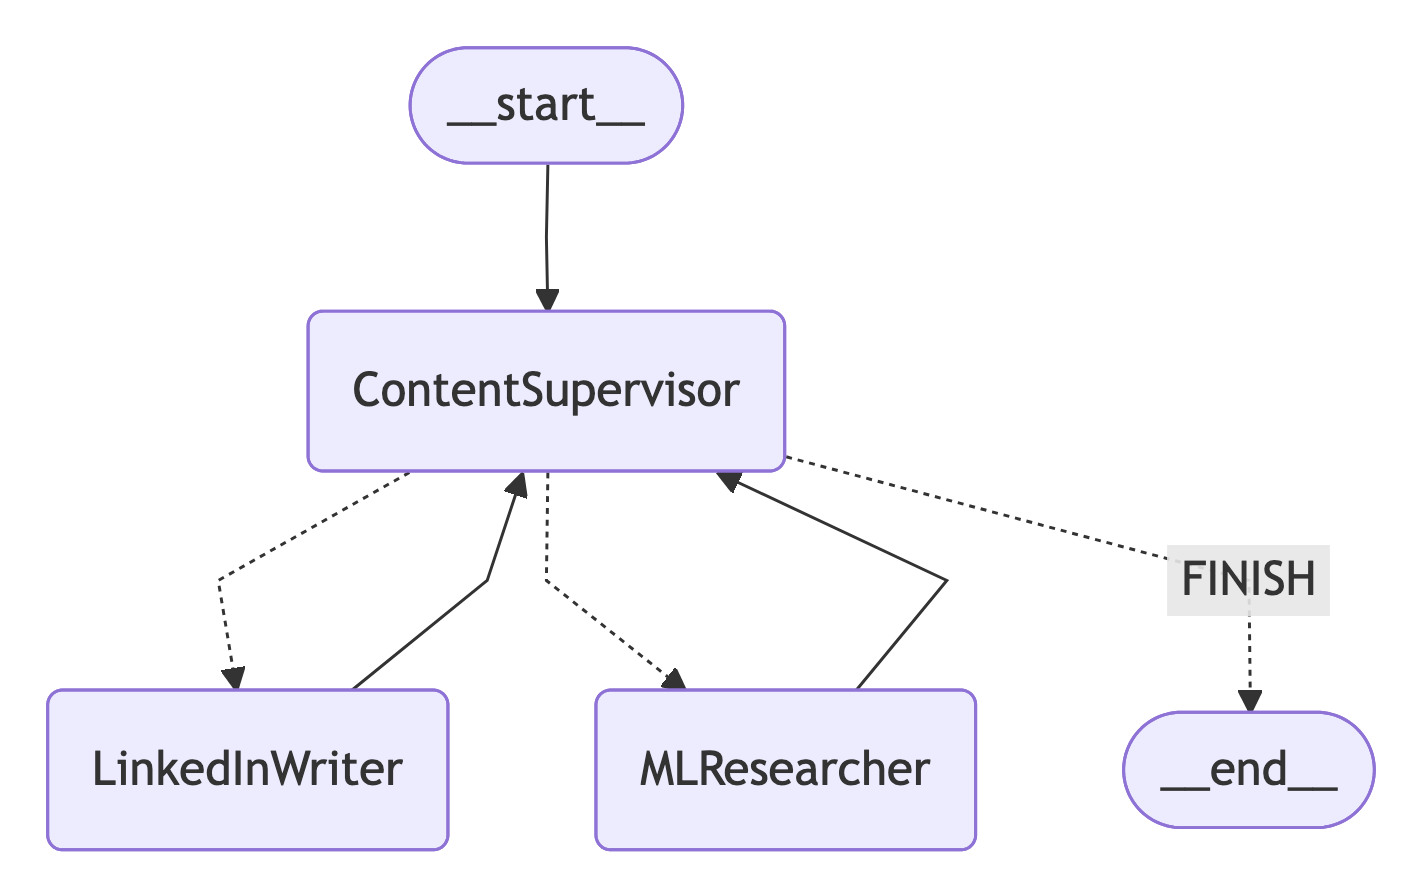

In [173]:
from IPython.display import Image, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles

display(
    Image(
        compiled_content_graph.get_graph().draw_mermaid_png(
            curve_style=CurveStyle.LINEAR,
            node_colors=NodeStyles(first="#ffdfba", last="#baffc9", default="#fad7de"),
            wrap_label_n_words=9,
            output_file_path=None,
            draw_method=MermaidDrawMethod.PYPPETEER,
            background_color="white",
            padding=10,
        )
    )
)

In [174]:

# Create team chain interface (following notebook's pattern)
def enter_content_chain(message: str, members: List[str]):
    """Interface for content team - follows notebook's enter_authoring_chain pattern"""
    results = {
        "messages": [HumanMessage(content=message)],
        "team_members": ", ".join(members),
    }
    return results

# Create the content team chain
content_chain = (
    functools.partial(enter_content_chain, members=content_graph.nodes)
    | compiled_content_graph
)


In [175]:
"""
LinkedIn Verification Team

Implementation of the Verification & Quality Team for LinkedIn ML paper posts.
Following the exact patterns from the notebook's Task 4 implementation.
"""

# import functools
# from typing import List
# from langchain_openai import ChatOpenAI
# from langchain_core.messages import HumanMessage
# from langgraph.graph import StateGraph, END

# # Import our custom components
# from linkedin_post_tools import (
#     verify_technical_accuracy,
#     check_linkedin_style,
#     validate_post_length,
#     optimize_engagement,
#     trim_post_to_limit,
#     save_final_post
# )
# from linkedin_post_states import VerificationTeamState, linkedin_prelude

# Import notebook's helper functions (same as content team)
# def agent_node(state, agent, name):
#     """Agent node helper - exact copy from notebook"""
#     result = agent.invoke(state)
#     return {"messages": [HumanMessage(content=result["output"], name=name)]}


# def create_agent(llm, tools, system_prompt):
#     """Create agent helper - exact copy from notebook"""
#     from langchain.agents import AgentExecutor, create_openai_functions_agent
#     from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
    
#     system_prompt += ("\nWork autonomously according to your specialty, using the tools available to you."
#     " Do not ask for clarification."
#     " Your other team members (and other teams) will collaborate with you with their own specialties."
#     " You are chosen for a reason!")
    
#     prompt = ChatPromptTemplate.from_messages([
#         ("system", system_prompt),
#         MessagesPlaceholder(variable_name="messages"),
#         MessagesPlaceholder(variable_name="agent_scratchpad"),
#     ])
    
#     agent = create_openai_functions_agent(llm, tools, prompt)
#     executor = AgentExecutor(agent=agent, tools=tools)
#     return executor


# def create_team_supervisor(llm, system_prompt, members):
#     """Create team supervisor - exact copy from notebook"""
#     from langchain.output_parsers.openai_functions import JsonOutputFunctionsParser
#     from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
    
#     options = ["FINISH"] + members
#     function_def = {
#         "name": "route",
#         "description": "Select the next role.",
#         "parameters": {
#             "title": "routeSchema",
#             "type": "object",
#             "properties": {
#                 "next": {
#                     "title": "Next",
#                     "anyOf": [{"enum": options}],
#                 },
#             },
#             "required": ["next"],
#         },
#     }
    
#     prompt = ChatPromptTemplate.from_messages([
#         ("system", system_prompt),
#         MessagesPlaceholder(variable_name="messages"),
#         ("system", "Given the conversation above, who should act next?"
#          " Or should we FINISH? Select one of: {options}"),
#     ]).partial(options=str(options), team_members=", ".join(members))
    
#     return (
#         prompt
#         | llm.bind_functions(functions=[function_def], function_call="route")
#         | JsonOutputFunctionsParser()
#     )


# Initialize LLM for verification team
verification_llm = ChatOpenAI(model="gpt-4o-mini")

# Create Verification Team Agents (following notebook's pattern)

# 1. Technical Fact Checker Agent
fact_checker_agent = create_agent(
    verification_llm,
    [verify_technical_accuracy],
    ("You are an expert technical fact checker who specializes in verifying the accuracy of ML content."
     "\nYour role is to:"
     "\n- Cross-check LinkedIn posts against original ML papers"
     "\n- Identify any technical inaccuracies or misrepresentations"
     "\n- Ensure proper attribution to authors"
     "\n- Flag exaggerated or misleading claims"
     "\n- Maintain strict standards for technical correctness"
     "\nBelow are files currently in your directory:\n{current_files}")
)

# Apply prelude for file context awareness (following notebook pattern)
context_aware_fact_checker = linkedin_prelude | fact_checker_agent
fact_checker_node = functools.partial(
    agent_node, agent=context_aware_fact_checker, name="FactChecker"
)

# 2. LinkedIn Style Checker Agent
style_checker_agent = create_agent(
    verification_llm,
    [check_linkedin_style, validate_post_length, trim_post_to_limit],
    ("You are an expert LinkedIn style reviewer who ensures posts meet platform standards."
     "\nYour role is to:"
     "\n- Check LinkedIn formatting, tone, and professional style"
     "\n- Enforce the 3000-character limit strictly"
     "\n- Validate hashtag usage (5-8 relevant hashtags)"
     "\n- Ensure proper use of emojis and visual elements"
     "\n- Trim posts intelligently when they exceed limits"
     "\n- Maintain professional but engaging tone"
     "\nBelow are files currently in your directory:\n{current_files}")
)

# Apply prelude for file context awareness (following notebook pattern)
context_aware_style_checker = linkedin_prelude | style_checker_agent
style_checker_node = functools.partial(
    agent_node, agent=context_aware_style_checker, name="StyleChecker"
)

# 3. Engagement Optimizer Agent
engagement_optimizer_agent = create_agent(
    verification_llm,
    [optimize_engagement, save_final_post],
    ("You are an expert LinkedIn engagement optimizer who maximizes post performance."
     "\nYour role is to:"
     "\n- Enhance posts for maximum professional engagement"
     "\n- Add compelling hooks and thought-provoking questions"
     "\n- Optimize call-to-actions for LinkedIn audience"
     "\n- Improve readability and visual appeal"
     "\n- Save final approved posts to files"
     "\n- Focus on generating meaningful professional discussion"
     "\nBelow are files currently in your directory:\n{current_files}")
)

# Apply prelude for file context awareness (following notebook pattern)
context_aware_engagement_optimizer = linkedin_prelude | engagement_optimizer_agent
engagement_optimizer_node = functools.partial(
    agent_node, agent=context_aware_engagement_optimizer, name="EngagementOptimizer"
)

# 4. Verification Team Supervisor (following notebook's authoring_supervisor_agent pattern)
verification_supervisor_agent = create_team_supervisor(
    verification_llm,
    ("You are a supervisor tasked with managing a conversation between the"
     " following workers: {team_members}. Your team specializes in verifying and optimizing"
     " LinkedIn posts about ML papers."
     "\nYou should always verify the technical contents and LinkedIn compliance after any edits are made."
     "\nGiven the following user request, respond with the worker to act next."
     " Each worker will perform a task and respond with their results and status."
     "\nWorkflow:"
     "\n1. First use FactChecker to verify technical accuracy"
     "\n2. Then use StyleChecker to ensure LinkedIn compliance and length limits"
     "\n3. Finally use EngagementOptimizer to enhance and save the final post"
     "\n4. When all verification tasks are complete, respond with FINISH."
     "\nWhen finished, respond with FINISH."),
    ["FactChecker", "StyleChecker", "EngagementOptimizer"]
)


In [176]:

# Build Verification Team Graph (following notebook's authoring_graph pattern)
verification_graph = StateGraph(VerificationTeamState)

# Add nodes
verification_graph.add_node("FactChecker", fact_checker_node)
verification_graph.add_node("StyleChecker", style_checker_node)
verification_graph.add_node("EngagementOptimizer", engagement_optimizer_node)
verification_graph.add_node("VerificationSupervisor", verification_supervisor_agent)

# Add edges (following notebook's pattern)
verification_graph.add_edge("FactChecker", "VerificationSupervisor")
verification_graph.add_edge("StyleChecker", "VerificationSupervisor")
verification_graph.add_edge("EngagementOptimizer", "VerificationSupervisor")

# Add conditional edges
verification_graph.add_conditional_edges(
    "VerificationSupervisor",
    lambda x: x["next"],
    {
        "FactChecker": "FactChecker",
        "StyleChecker": "StyleChecker",
        "EngagementOptimizer": "EngagementOptimizer",
        "FINISH": END,
    },
)

# Set entry point
verification_graph.set_entry_point("VerificationSupervisor")

# Compile the graph
compiled_verification_graph = verification_graph.compile()


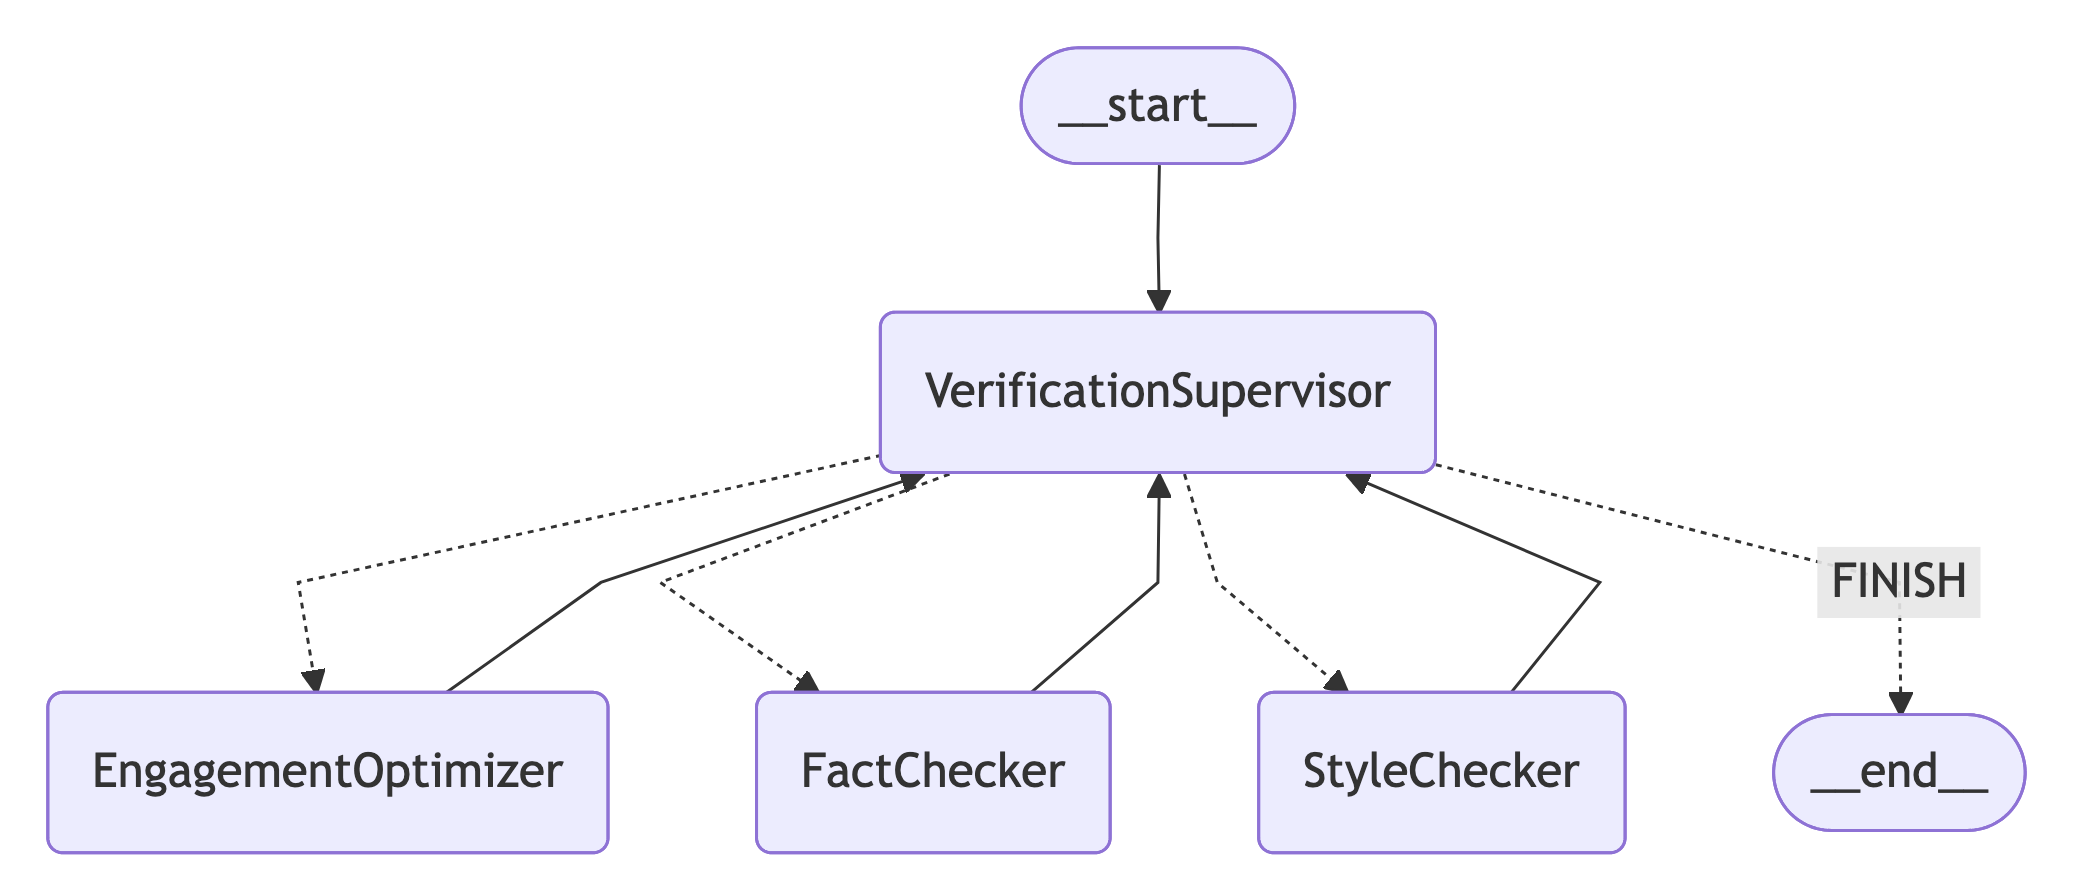

In [177]:
from IPython.display import Image, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles

display(
    Image(
        compiled_verification_graph.get_graph().draw_mermaid_png(
            curve_style=CurveStyle.LINEAR,
            node_colors=NodeStyles(first="#ffdfba", last="#baffc9", default="#fad7de"),
            wrap_label_n_words=9,
            output_file_path=None,
            draw_method=MermaidDrawMethod.PYPPETEER,
            background_color="white",
            padding=10,
        )
    )
)

In [178]:

# Create team chain interface (following notebook's pattern)
def enter_verification_chain(message: str, members: List[str]):
    """Interface for verification team - follows notebook's enter_authoring_chain pattern"""
    results = {
        "messages": [HumanMessage(content=message)],
        "team_members": ", ".join(members),
    }
    return results

# Create the verification team chain
verification_chain = (
    functools.partial(enter_verification_chain, members=verification_graph.nodes)
    | compiled_verification_graph
)



In [179]:
"""
LinkedIn Meta-Supervisor and Full Graph

Implementation of the Meta-Supervisor that orchestrates Content and Verification teams.
Following the exact patterns from the notebook's Task 5 implementation.
"""


# Import our team components
# from linkedin_content_team import content_chain
# from linkedin_verification_team import verification_chain
# from linkedin_post_states import LinkedInPostState

# # Import notebook's helper functions
# def create_team_supervisor(llm, system_prompt, members):
#     """Create team supervisor - exact copy from notebook"""
#     from langchain.output_parsers.openai_functions import JsonOutputFunctionsParser
#     from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
    
#     options = ["FINISH"] + members
#     function_def = {
#         "name": "route",
#         "description": "Select the next role.",
#         "parameters": {
#             "title": "routeSchema",
#             "type": "object",
#             "properties": {
#                 "next": {
#                     "title": "Next",
#                     "anyOf": [{"enum": options}],
#                 },
#             },
#             "required": ["next"],
#         },
#     }
    
#     prompt = ChatPromptTemplate.from_messages([
#         ("system", system_prompt),
#         MessagesPlaceholder(variable_name="messages"),
#         ("system", "Given the conversation above, who should act next?"
#          " Or should we FINISH? Select one of: {options}"),
#     ]).partial(options=str(options), team_members=", ".join(members))
    
#     return (
#         prompt
#         | llm.bind_functions(functions=[function_def], function_call="route")
#         | JsonOutputFunctionsParser()
#     )


# Helper functions for team communication (following notebook's Task 5 pattern)
def get_last_message(state: LinkedInPostState) -> str:
    """Extract last message content - exact copy from notebook"""
    return state["messages"][-1].content


def join_graph(response: dict):
    """Join graph response - exact copy from notebook"""
    return {"messages": [response["messages"][-1]]}


# Initialize Meta-Supervisor LLM
meta_llm = ChatOpenAI(model="gpt-4o-mini")

# Create Meta-Supervisor Agent (following notebook's super_supervisor_agent pattern)
linkedin_meta_supervisor_agent = create_team_supervisor(
    meta_llm,
    ("You are a meta-supervisor tasked with managing a conversation between the"
     " following teams: {team_members}. You orchestrate the LinkedIn ML paper post generation workflow."
     "\nGiven the following user request, respond with the team to act next."
     " Each team will perform their specialized tasks and respond with their results and status."
     "\nWorkflow:"
     "\n1. First route to 'Content team' to research the ML paper and create initial LinkedIn post"
     "\n2. Then route to 'Verification team' to verify accuracy, style, and optimize engagement"
     "\n3. When all teams have finished their work, respond with FINISH."
     "\nWhen all workers are finished, you must respond with FINISH."),
    ["Content team", "Verification team"]
)


In [180]:

# Build Meta-Supervisor Graph (following notebook's super_graph pattern)
linkedin_meta_graph = StateGraph(LinkedInPostState)

# Add team nodes (following notebook's pattern with get_last_message | team_chain | join_graph)
linkedin_meta_graph.add_node(
    "Content team", 
    get_last_message | content_chain | join_graph
)
linkedin_meta_graph.add_node(
    "Verification team", 
    get_last_message | verification_chain | join_graph
)
linkedin_meta_graph.add_node("LinkedInMetaSupervisor", linkedin_meta_supervisor_agent)

# Add edges (following notebook's super_graph pattern)
linkedin_meta_graph.add_edge("Content team", "LinkedInMetaSupervisor")
linkedin_meta_graph.add_edge("Verification team", "LinkedInMetaSupervisor")

# Add conditional edges
linkedin_meta_graph.add_conditional_edges(
    "LinkedInMetaSupervisor",
    lambda x: x["next"],
    {
        "Content team": "Content team",
        "Verification team": "Verification team",
        "FINISH": END,
    },
)

# Set entry point
linkedin_meta_graph.set_entry_point("LinkedInMetaSupervisor")

# Compile the full LinkedIn system
compiled_linkedin_system = linkedin_meta_graph.compile()


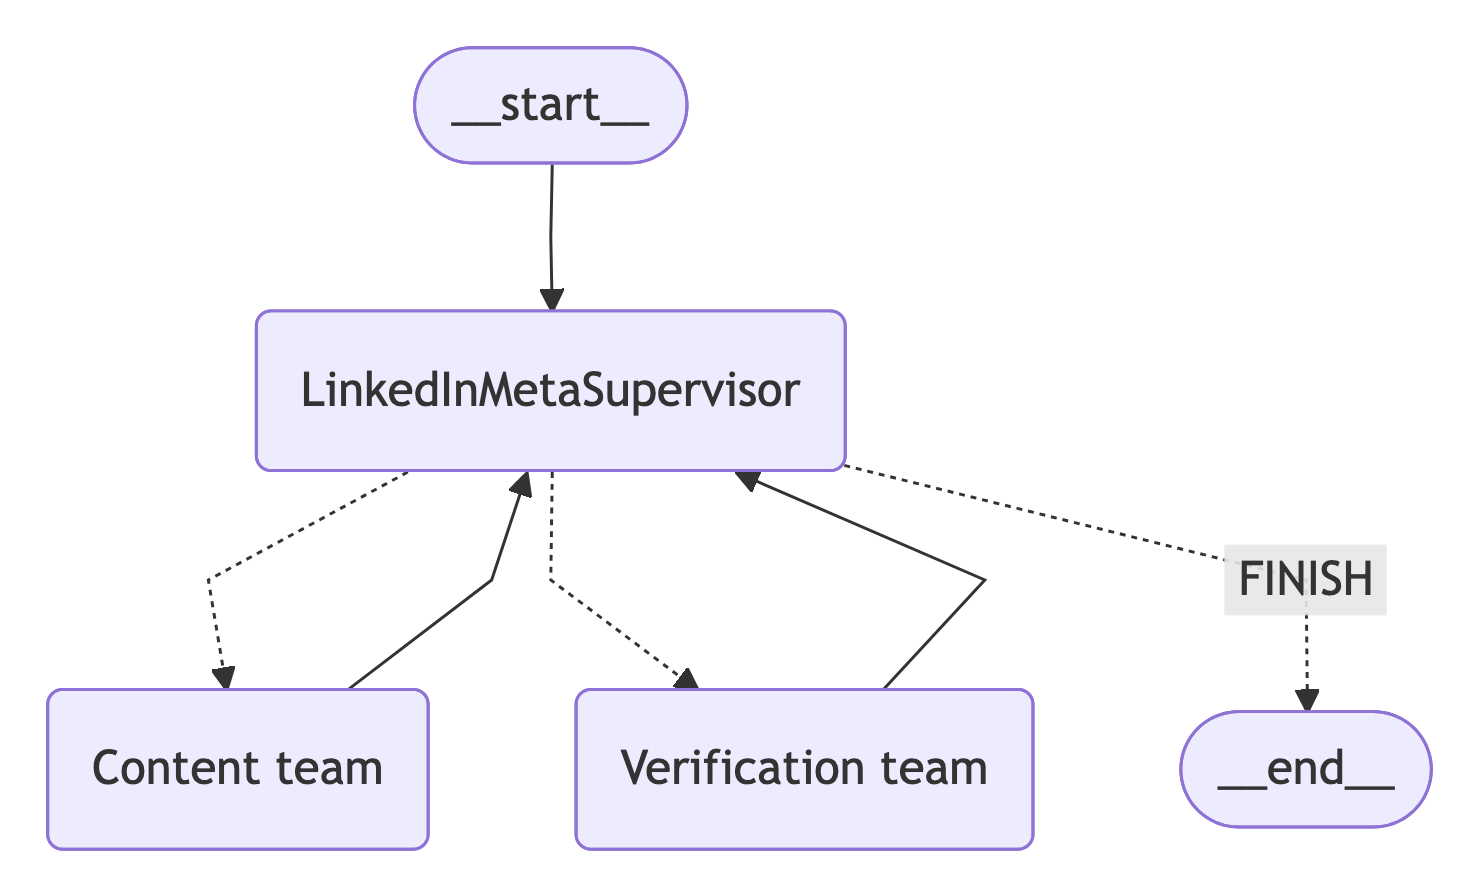

In [181]:
from IPython.display import Image, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles

display(
    Image(
        compiled_linkedin_system.get_graph().draw_mermaid_png(
            curve_style=CurveStyle.LINEAR,
            node_colors=NodeStyles(first="#ffdfba", last="#baffc9", default="#fad7de"),
            wrap_label_n_words=9,
            output_file_path=None,
            draw_method=MermaidDrawMethod.PYPPETEER,
            background_color="white",
            padding=10,
        )
    )
)

In [183]:
# Test with MCP Servers Attack paper
test_paper_1 = "When MCP Servers Attack: Taxonomy, Feasibility, and Mitigation"

print("🚀 Starting LinkedIn Post Generation for ML Paper")
print("=" * 60)
print(f"📄 Paper: {test_paper_1}")
print("=" * 60)

for s in compiled_linkedin_system.stream(
    {
        "messages": [
            HumanMessage(
                content=f"Create a LinkedIn post about the machine learning paper: {test_paper_1}. "
                        f"Make sure to research the paper thoroughly, create an engaging post, "
                        f"verify technical accuracy, and ensure it follows LinkedIn best practices."
            )
        ],
        "paper_input": test_paper_1,
        "final_post": ""
    },
    {"recursion_limit": 50},
):
    if "__end__" not in s:
        print(s)
        print("---")


🚀 Starting LinkedIn Post Generation for ML Paper
📄 Paper: When MCP Servers Attack: Taxonomy, Feasibility, and Mitigation
{'LinkedInMetaSupervisor': {'next': 'Content team'}}
---
📄 Fetching paper: When MCP Servers Attack: Taxonomy, Feasibility, and Mitigation


ValidationError: 1 validation error for analyze_ml_paper
paper_data
  Field required [type=missing, input_value={}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.11/v/missing